# CLEANING FOR CUSTOMER_COMMENT & SURVEY & PASSANGER TABLES

In [799]:
import pandas as pd
import os

# Read the CSV files with correct file names
cc = pd.read_csv(r"../../Customer_comment.csv")
sd = pd.read_csv(r"../../Survey data_Inflight Satisfaction Score.csv")
pb = pd.read_csv(r"../../Passanger_booking_data.csv")

In [800]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [801]:
cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9424 entries, 0 to 9423
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                9424 non-null   int64 
 1   flight_number             9424 non-null   int64 
 2   origin_station_code       9424 non-null   object
 3   destination_station_code  9424 non-null   object
 4   scheduled_departure_date  9424 non-null   object
 5   arrival_delay_group       9424 non-null   object
 6   departure_delay_group     9424 non-null   object
 7   entity                    9424 non-null   object
 8   verbatim_text             9424 non-null   object
 9   seat_factor_band          9424 non-null   object
 10  ques_verbatim_text        9424 non-null   object
 11  loyalty_program_level     6920 non-null   object
 12  fleet_type_description    9424 non-null   object
 13  fleet_usage               9424 non-null   object
 14  response_group          

In [802]:
cc.describe()

,Unnamed: 0,flight_number
count,9424.000000,9424.000000
mean,4711.500000,1741.573430
std,2720.618802,1550.550037
min,0.000000,2.000000
25%,2355.750000,614.000000
50%,4711.500000,1286.000000
75%,7067.250000,2261.000000
max,9423.000000,6375.000000


In [803]:
cc.describe(include=['object'])

,origin_station_code,destination_station_code,scheduled_departure_date,arrival_delay_group,departure_delay_group,entity,verbatim_text,seat_factor_band,ques_verbatim_text,loyalty_program_level,fleet_type_description,fleet_usage,response_group,sentiments,transformed_text
count,9424,9424,9424,9424,9424,9424,9424,9424,9424,6920,9424,9424,9424,9424,8405
unique,195,192,30,2,2,4,8013,4,1,7,22,2,3,2,7609
top,IAX,IAX,2022-09-10,Early & Ontime,Early & Ontime,Domestic,No.,90+,Is there anything else you'd like to share abo...,non-elite,B737-900,Mainline,member,Neutral,none
freq,1149,1427,399,6811,6241,6593,774,6302,9424,4128,1451,7985,6905,9307,97


In [804]:
cc.isnull().sum()

Unnamed: 0                     0
flight_number                  0
origin_station_code            0
destination_station_code       0
scheduled_departure_date       0
arrival_delay_group            0
departure_delay_group          0
entity                         0
verbatim_text                  0
seat_factor_band               0
ques_verbatim_text             0
loyalty_program_level       2504
fleet_type_description         0
fleet_usage                    0
response_group                 0
sentiments                     0
transformed_text            1019
dtype: int64

In [805]:
cc["loyalty_program_level"].value_counts()

loyalty_program_level
non-elite           4128
premier silver       874
premier 1k           722
premier gold         604
premier platinum     451
global services      140
NBK                    1
Name: count, dtype: int64

In [806]:
# Drop rows where loyalty_program_level is 'nbk' since there is only one occurrence
cc = cc[cc["loyalty_program_level"] != "NBK"]
cc["loyalty_program_level"].value_counts()

loyalty_program_level
non-elite           4128
premier silver       874
premier 1k           722
premier gold         604
premier platinum     451
global services      140
Name: count, dtype: int64

In [807]:
# Fill null values in loyalty_program_level with "No Program" 
# since normally you have to enroll to a loyalty program manually 
# so assume they are not in one
cc["loyalty_program_level"].fillna("No Program", inplace=True)
print(cc["loyalty_program_level"].value_counts())

loyalty_program_level
non-elite           4128
No Program          2504
premier silver       874
premier 1k           722
premier gold         604
premier platinum     451
global services      140
Name: count, dtype: int64


In [808]:
cc["transformed_text"].fillna("No Comment", inplace=True)
cc.isnull().sum()
#end customer comment data cleaning

Unnamed: 0                  0
flight_number               0
origin_station_code         0
destination_station_code    0
scheduled_departure_date    0
arrival_delay_group         0
departure_delay_group       0
entity                      0
verbatim_text               0
seat_factor_band            0
ques_verbatim_text          0
loyalty_program_level       0
fleet_type_description      0
fleet_usage                 0
response_group              0
sentiments                  0
transformed_text            0
dtype: int64

In [809]:
pb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50002 entries, 0 to 50001
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50002 non-null  int64  
 1   sales_channel          50002 non-null  object 
 2   trip_type              50002 non-null  object 
 3   purchase_lead          50002 non-null  int64  
 4   length_of_stay         50002 non-null  int64  
 5   flight_hour            50002 non-null  int64  
 6   flight_day             50002 non-null  object 
 7   route                  50002 non-null  object 
 8   booking_origin         50002 non-null  object 
 9   wants_extra_baggage    50002 non-null  int64  
 10  wants_preferred_seat   50002 non-null  int64  
 11  wants_in_flight_meals  50002 non-null  int64  
 12  flight_duration        50002 non-null  float64
 13  booking_complete       50002 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [810]:
pb.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50002.000000,50002.000000,50002.000000,50002.000000,50002.000000,50002.000000,50002.000000,50002.000000,50002.000000
mean,1.591256,84.940582,23.044778,9.066277,0.668773,0.296968,0.427143,7.277524,0.149574
std,1.020167,90.450548,33.887171,5.412569,0.470659,0.456927,0.494668,1.496854,0.356657
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.000000,5.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.000000,9.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.000000,13.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.000000,23.000000,1.000000,1.000000,1.000000,9.500000,1.000000


In [811]:
pb.describe(include=['object'])

,sales_channel,trip_type,flight_day,route,booking_origin
count,50002,50002,50002,50002,50002
unique,2,3,7,799,104
top,Internet,RoundTrip,Mon,AKLKUL,Australia
freq,44383,49498,8102,2680,17873


In [812]:
duplicatespb = pb[pb.duplicated()]
duplicatespb.shape

(719, 14)

In [813]:
# Remove duplicates
pb=pb.drop_duplicates()
pb.shape
#end passanger booking data cleaning since no nulls

(49283, 14)

In [814]:
sd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47074 entries, 0 to 47073
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   flight_number                     47074 non-null  int64 
 1   origin_station_code               47074 non-null  object
 2   destination_station_code          47074 non-null  object
 3   record_locator                    47074 non-null  object
 4   scheduled_departure_date          47074 non-null  object
 5   question_text                     47074 non-null  object
 6   score                             47074 non-null  object
 7   satisfaction_type                 34963 non-null  object
 8   driver_sub_group1                 47074 non-null  object
 9   driver_sub_group2                 47074 non-null  object
 10  arrival_delay_minutes             47074 non-null  int64 
 11  arrival_delay_group               47074 non-null  object
 12  cabin_code_desc   

In [815]:
sd.describe()

,flight_number,arrival_delay_minutes,number_of_legs,actual_flown_miles
count,47074.000000,47074.000000,47074.000000,47074.000000
mean,1529.855207,-1.702490,1.344118,2477.737732
std,1456.712299,37.868177,0.502424,1865.646538
min,2.000000,-104.000000,1.000000,45.000000
25%,477.000000,-19.000000,1.000000,932.000000
50%,1050.000000,-9.000000,1.000000,1846.000000
75%,2060.000000,4.000000,2.000000,3870.000000
max,6376.000000,907.000000,3.000000,8440.000000


In [816]:
sd.describe(include=['object'])

,origin_station_code,destination_station_code,record_locator,scheduled_departure_date,question_text,score,satisfaction_type,driver_sub_group1,driver_sub_group2,arrival_delay_group,cabin_code_desc,cabin_name,entity,seat_factor_band,loyalty_program_level,generation,fleet_type_description,fleet_usage,equipment_type_code,ua_uax,haul_type,departure_gate,arrival_gate,international_domestic_indicator,response_group,media_provider,hub_spoke
count,47074,47074,47074,47074,47074,47074,34963,47074,47074,47074,47074,27094,47071,47074,35458,47074,47074,47074,47074,47074,47074,46977,46547,47074,47074,45535,47074
unique,213,212,33095,30,2,12,2,1,2,2,3,2,4,4,7,7,22,2,40,2,3,656,692,2,3,4,2
top,IAX,EWX,JNXXVS,9/10/2022,How satisfied were you with the food & beverag...,2,Dissatisfied,food & beverage,food and beverage satisfaction,Early & Ontime,Economy,Economy,Domestic,90+,non-elite,Boomer,B737-900,Mainline,37K,UA,Medium,A8,HOLD,Domestic,member,PANASONIC,hub departure
freq,5758,7058,6,1872,34963,8250,22353,47074,34963,32868,27094,18438,29242,31718,19331,22282,6838,41628,6366,41628,26423,589,965,29242,35382,24979,24343


In [817]:
# Set pandas display options to show all rows
pd.set_option('display.max_rows', None)

# Display null counts
print(sd.isnull().sum())

# Optionally reset display options back to default
pd.reset_option('display.max_rows')

flight_number                           0
origin_station_code                     0
destination_station_code                0
record_locator                          0
scheduled_departure_date                0
question_text                           0
score                                   0
satisfaction_type                   12111
driver_sub_group1                       0
driver_sub_group2                       0
arrival_delay_minutes                   0
arrival_delay_group                     0
cabin_code_desc                         0
cabin_name                          19980
entity                                  3
number_of_legs                          0
seat_factor_band                        0
loyalty_program_level               11616
generation                              0
fleet_type_description                  0
fleet_usage                             0
equipment_type_code                     0
ua_uax                                  0
actual_flown_miles                

In [818]:
sd['media_provider'].value_counts()

media_provider
PANASONIC    24979
THALES       12765
GOGO          3907
VIASAT        3884
Name: count, dtype: int64

In [819]:
sd["media_provider"].fillna("No Media", inplace=True)

In [820]:
sd['arrival_gate'].value_counts()

arrival_gate
HOLD    965
B55     480
A8      443
C5      435
C3      434
       ... 
89        1
A5F       1
A3E       1
410       1
-2-       1
Name: count, Length: 692, dtype: int64

In [821]:

sd=sd.dropna(subset=['arrival_gate'])


In [822]:
sd.isnull().sum()

flight_number                           0
origin_station_code                     0
destination_station_code                0
record_locator                          0
scheduled_departure_date                0
question_text                           0
score                                   0
satisfaction_type                   12098
driver_sub_group1                       0
driver_sub_group2                       0
arrival_delay_minutes                   0
arrival_delay_group                     0
cabin_code_desc                         0
cabin_name                          19899
entity                                  3
number_of_legs                          0
seat_factor_band                        0
loyalty_program_level               11452
generation                              0
fleet_type_description                  0
fleet_usage                             0
equipment_type_code                     0
ua_uax                                  0
actual_flown_miles                

In [823]:
sd=sd.dropna(subset=['departure_gate'])

In [824]:
sd["loyalty_program_level"].value_counts()

loyalty_program_level
non-elite           19041
premier silver       4803
premier 1k           4305
premier gold         3329
premier platinum     2616
global services       930
NBK                     3
Name: count, dtype: int64

In [825]:
# Drop rows where loyalty_program_level is 'nbk' since there is only 3 occurrence
sd = sd[sd["loyalty_program_level"] != "NBK"]

# Fill null values in loyalty_program_level with "No Program" 
# since normally you have to enroll to a loyalty program manually 
# so assume they are not in one
sd["loyalty_program_level"].fillna("No Program", inplace=True)
sd["loyalty_program_level"].value_counts()

loyalty_program_level
non-elite           19041
No Program          11424
premier silver       4803
premier 1k           4305
premier gold         3329
premier platinum     2616
global services       930
Name: count, dtype: int64

In [826]:
sd.isnull().sum()

flight_number                           0
origin_station_code                     0
destination_station_code                0
record_locator                          0
scheduled_departure_date                0
question_text                           0
score                                   0
satisfaction_type                   12094
driver_sub_group1                       0
driver_sub_group2                       0
arrival_delay_minutes                   0
arrival_delay_group                     0
cabin_code_desc                         0
cabin_name                          19888
entity                                  3
number_of_legs                          0
seat_factor_band                        0
loyalty_program_level                   0
generation                              0
fleet_type_description                  0
fleet_usage                             0
equipment_type_code                     0
ua_uax                                  0
actual_flown_miles                

In [827]:
sd['entity'].value_counts()

entity
Domestic    28625
Atlantic    12904
Latin        3371
Pacific      1545
Name: count, dtype: int64

In [828]:
sd.head(5)

,flight_number,origin_station_code,destination_station_code,record_locator,scheduled_departure_date,question_text,score,satisfaction_type,driver_sub_group1,driver_sub_group2,arrival_delay_minutes,arrival_delay_group,cabin_code_desc,cabin_name,entity,number_of_legs,seat_factor_band,loyalty_program_level,generation,fleet_type_description,fleet_usage,equipment_type_code,ua_uax,actual_flown_miles,haul_type,departure_gate,arrival_gate,international_domestic_indicator,response_group,media_provider,hub_spoke
0,3802,MKX,ORX,CYXXJJ,9/1/2022,How satisfied were you with the food & beverag...,2,Dissatisfied,food & beverage,food and beverage satisfaction,-24,Early & Ontime,Economy,Economy,Domestic,2,80+,No Program,Gen X,CRJ-200,Express,CRZ,UAX,67,Short,C12,F10,Domestic,non-member,No Media,spoke departure
1,4645,COX,DEX,DRXXMH,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,10,Delayed,Business,NaN,Domestic,2,90+,premier platinum,Boomer,ERJ-175,Express,E75,UAX,72,Short,5,B60,Domestic,member,GOGO,spoke departure
2,5236,COX,DEX,DEXXS1,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,-8,Early & Ontime,Business,NaN,Domestic,2,90+,premier platinum,Gen X,ERJ-175,Express,E75,UAX,72,Short,7,A71,Domestic,member,GOGO,spoke departure
3,4686,DEX,COX,PXXXLH,9/1/2022,How satisfied were you with the food & beverag...,3,Dissatisfied,food & beverage,food and beverage satisfaction,-11,Early & Ontime,Economy,Economy,Domestic,3,90+,non-elite,Boomer,CRJ-200,Express,CRJ,UAX,72,Short,B82,5,Domestic,member,No Media,hub departure
4,671,DEX,COX,KZXXH5,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,18,Delayed,Business,NaN,Domestic,2,90+,premier silver,Boomer,A319-100,Mainline,19F,UA,72,Short,B24,3,Domestic,member,PANASONIC,hub departure


In [829]:
sd[sd["entity"].isna()]

,flight_number,origin_station_code,destination_station_code,record_locator,scheduled_departure_date,question_text,score,satisfaction_type,driver_sub_group1,driver_sub_group2,arrival_delay_minutes,arrival_delay_group,cabin_code_desc,cabin_name,entity,number_of_legs,seat_factor_band,loyalty_program_level,generation,fleet_type_description,fleet_usage,equipment_type_code,ua_uax,actual_flown_miles,haul_type,departure_gate,arrival_gate,international_domestic_indicator,response_group,media_provider,hub_spoke
39948,3020,SJX,PTX,A3XX7C,9/26/2022,How satisfied were you with the food & beverag...,1,Dissatisfied,food & beverage,food and beverage satisfaction,15,Delayed,Economy,Economy,NaN,1,80+,non-elite,Boomer,B737-900,Mainline,37K,UA,335,Short,8,137,International,member,VIASAT,spoke departure
39949,3020,SJX,PTX,AFXX8Y,9/26/2022,How satisfied were you with the food & beverag...,1,Dissatisfied,food & beverage,food and beverage satisfaction,15,Delayed,Economy,Economy Plus,NaN,1,80+,premier gold,Gen X,B737-900,Mainline,37K,UA,335,Short,8,137,International,member,VIASAT,spoke departure
39950,3020,SJX,PTX,A5XX47,9/26/2022,How satisfied were you with the food & beverag...,1,Dissatisfied,food & beverage,food and beverage satisfaction,15,Delayed,Economy,Economy Plus,NaN,1,80+,premier silver,Millennial,B737-900,Mainline,37K,UA,335,Short,8,137,International,member,VIASAT,spoke departure


In [830]:
#because this these flight departure from a city in Latin America so entity is Latin
sd["entity"].fillna("Latin", inplace=True)

In [831]:
sd["cabin_code_desc"].value_counts()

cabin_code_desc
Economy                26560
Business               17926
United Premium Plus     1962
Name: count, dtype: int64

In [832]:
sd["cabin_name"].value_counts()

cabin_name
Economy         17968
Economy Plus     8592
Name: count, dtype: int64

In [833]:
# Merged columns since it doesnt make sense to have two columns for cabin class 
sd['cabin_name'] = sd['cabin_name'].fillna(sd['cabin_code_desc'])
sd = sd.drop(columns=['cabin_code_desc'])
sd = sd.rename(columns={'cabin_name': 'cabin_class'})

In [834]:
sd["cabin_class"].value_counts()

cabin_class
Economy                17968
Business               17926
Economy Plus            8592
United Premium Plus     1962
Name: count, dtype: int64

In [835]:
sd.isnull().sum()

flight_number                           0
origin_station_code                     0
destination_station_code                0
record_locator                          0
scheduled_departure_date                0
question_text                           0
score                                   0
satisfaction_type                   12094
driver_sub_group1                       0
driver_sub_group2                       0
arrival_delay_minutes                   0
arrival_delay_group                     0
cabin_class                             0
entity                                  0
number_of_legs                          0
seat_factor_band                        0
loyalty_program_level                   0
generation                              0
fleet_type_description                  0
fleet_usage                             0
equipment_type_code                     0
ua_uax                                  0
actual_flown_miles                      0
haul_type                         

In [836]:
sd["satisfaction_type"].value_counts()

satisfaction_type
Dissatisfied    21977
Satisfied       12377
Name: count, dtype: int64

In [837]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sd.head(5)

,flight_number,origin_station_code,destination_station_code,record_locator,scheduled_departure_date,question_text,score,satisfaction_type,driver_sub_group1,driver_sub_group2,arrival_delay_minutes,arrival_delay_group,cabin_class,entity,number_of_legs,seat_factor_band,loyalty_program_level,generation,fleet_type_description,fleet_usage,equipment_type_code,ua_uax,actual_flown_miles,haul_type,departure_gate,arrival_gate,international_domestic_indicator,response_group,media_provider,hub_spoke
0,3802,MKX,ORX,CYXXJJ,9/1/2022,How satisfied were you with the food & beverag...,2,Dissatisfied,food & beverage,food and beverage satisfaction,-24,Early & Ontime,Economy,Domestic,2,80+,No Program,Gen X,CRJ-200,Express,CRZ,UAX,67,Short,C12,F10,Domestic,non-member,No Media,spoke departure
1,4645,COX,DEX,DRXXMH,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,10,Delayed,Business,Domestic,2,90+,premier platinum,Boomer,ERJ-175,Express,E75,UAX,72,Short,5,B60,Domestic,member,GOGO,spoke departure
2,5236,COX,DEX,DEXXS1,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,-8,Early & Ontime,Business,Domestic,2,90+,premier platinum,Gen X,ERJ-175,Express,E75,UAX,72,Short,7,A71,Domestic,member,GOGO,spoke departure
3,4686,DEX,COX,PXXXLH,9/1/2022,How satisfied were you with the food & beverag...,3,Dissatisfied,food & beverage,food and beverage satisfaction,-11,Early & Ontime,Economy,Domestic,3,90+,non-elite,Boomer,CRJ-200,Express,CRJ,UAX,72,Short,B82,5,Domestic,member,No Media,hub departure
4,671,DEX,COX,KZXXH5,9/1/2022,How satisfied were you with the food & beverag...,5,Satisfied,food & beverage,food and beverage satisfaction,18,Delayed,Business,Domestic,2,90+,premier silver,Boomer,A319-100,Mainline,19F,UA,72,Short,B24,3,Domestic,member,PANASONIC,hub departure


In [838]:
# The trend in the rows is that satisfaction type is dependent on the score
# so if score is 4 or 5 we can use this to fill in the missing values
mask = sd["satisfaction_type"].isna()
sd.loc[mask, "satisfaction_type"] = np.where(
    (sd.loc[mask, "score"] == "4") | (sd.loc[mask, "score"] == "5"),
    "Satisfied",
    "Dissatisfied"
)

In [839]:
sd.isnull().sum()

flight_number                       0
origin_station_code                 0
destination_station_code            0
record_locator                      0
scheduled_departure_date            0
question_text                       0
score                               0
satisfaction_type                   0
driver_sub_group1                   0
driver_sub_group2                   0
arrival_delay_minutes               0
arrival_delay_group                 0
cabin_class                         0
entity                              0
number_of_legs                      0
seat_factor_band                    0
loyalty_program_level               0
generation                          0
fleet_type_description              0
fleet_usage                         0
equipment_type_code                 0
ua_uax                              0
actual_flown_miles                  0
haul_type                           0
departure_gate                      0
arrival_gate                        0
internationa

In [840]:
print(sd.shape)
sd=sd.drop_duplicates()
print(sd.shape)

(46448, 30)
(46448, 30)


### CLEANING SCRAPPED_REVIEWS

In [841]:
asr=pd.read_csv(r'../../AirlineScrappedReview_Cleaned.csv')

In [842]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3575 entries, 0 to 3574
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   3500 non-null   object 
 1   Flying_Date      955 non-null    object 
 2   Route            2807 non-null   object 
 3   Rating           3501 non-null   float64
 4   Verified         3501 non-null   object 
 5   Review_title     3501 non-null   object 
 6   Review_content   3501 non-null   object 
 7   Traveller_Type   3501 non-null   object 
 8   Class            3501 non-null   object 
 9   Start_Location   2807 non-null   object 
 10  End_Location     2807 non-null   object 
 11  Layover_Route    484 non-null    object 
 12  Start_Latitude   3441 non-null   float64
 13  Start_Longitude  3441 non-null   float64
 14  Start_Address    3441 non-null   object 
 15  End_Latitude     3402 non-null   float64
 16  End_Longitude    3402 non-null   float64
 17  End_Address   

In [843]:
asr = asr.dropna(how='all')

In [844]:
asr=asr.drop(columns=['Flying_Date'],axis=1)

In [845]:
# For flights with no layover, fill Layover_Route with 'None'
asr['Layover_Route'] = asr['Layover_Route'].fillna('None')

In [846]:
asr_with_no_route_and_start_address_and_end_address = asr[asr['Route'].isnull() & asr['Start_Address'].notnull() & asr['End_Address'].notnull()][['Route','Start_Address','End_Address']]

In [847]:
print(len(asr_with_no_route_and_start_address_and_end_address))
print(asr_with_no_route_and_start_address_and_end_address.head())

694
     Route                                      Start_Address  \
42     NaN  Nanno, Ville d'Anaunia, Comunità della Val di ...   
234    NaN  Nanno, Ville d'Anaunia, Comunità della Val di ...   
419    NaN  Nanno, Ville d'Anaunia, Comunità della Val di ...   
2550   NaN  Nanno, Ville d'Anaunia, Comunità della Val di ...   
2565   NaN  Nanno, Ville d'Anaunia, Comunità della Val di ...   

                                            End_Address  
42    Nanno, Ville d'Anaunia, Comunità della Val di ...  
234   Nanno, Ville d'Anaunia, Comunità della Val di ...  
419   Nanno, Ville d'Anaunia, Comunità della Val di ...  
2550  Nanno, Ville d'Anaunia, Comunità della Val di ...  
2565  Nanno, Ville d'Anaunia, Comunità della Val di ...  


In [848]:
#Make sure it's invalid and only 1 value
asr_with_no_route_and_start_address_and_end_address['Start_Address'].value_counts()

Start_Address
Nanno, Ville d'Anaunia, Comunità della Val di Non, Provincia di Trento, Trentino-Alto Adige/Südtirol, 38093, Italia    694
Name: count, dtype: int64

In [849]:
asr.drop(asr_with_no_route_and_start_address_and_end_address.index, inplace=True)

In [850]:
asr['Route'] = asr['Route'].str.replace('Johannesburg', 'JNB')
asr['Route'] = asr['Route'].str.replace('Cape Town', 'CPT')
asr['Route'] = asr['Route'].str.replace('London Heathrow', 'LHR')
asr['Route'] = asr['Route'].str.replace('London Gatwick', 'LGW')
asr['Route'] = asr['Route'].str.replace('Hong Kong', 'HKG')
asr['Route'] = asr['Route'].str.replace(' to San Francisco', ' to SFO')
asr['Route'] = asr['Route'].str.replace('San Francisco to ', ' SFO to')
asr['Route'] = asr['Route'].str.replace('Rotterdam', 'RTM')
asr['Route'] = asr['Route'].str.replace('Muscat', 'MCT')
asr['Route'] = asr['Route'].str.replace('Lisbon', 'LIS')
asr['Route'] = asr['Route'].str.replace('London UK (Heathrow)', 'LHR')
asr['Route'] = asr['Route'].str.replace('London-Heathrow', 'LHR')
asr['Route'] = asr['Route'].str.replace('London Heathrow', 'LHR')
asr['Route'] = asr['Route'].str.replace(' via Heathrow', ' via LHR')
asr['Route'] = asr['Route'].str.replace(' to Heathrow', ' to LHR')
asr['Route'] = asr['Route'].str.replace('Heathrow to ', 'LHR to')
asr['Route'] = asr['Route'].str.replace(' toIbiza', ' to IBZ')
asr['Route'] = asr['Route'].str.replace('Ibiza', 'IBZ')
asr['Route'] = asr['Route'].str.replace(' toBodrum', ' to BJV')
asr['Route'] = asr['Route'].str.replace('Bodrum', 'BJV')
asr['Route'] = asr['Route'].str.replace('Aberdeen', 'ABZ')
asr['Route'] = asr['Route'].str.replace('Tampa', 'TPA')
asr['Route'] = asr['Route'].str.replace('Gatwick', 'LGW')
asr['Route'] = asr['Route'].str.replace('toDubai', 'to DXC')
asr['Route'] = asr['Route'].str.replace('toBarcelona', 'to BCN')
asr['Route'] = asr['Route'].str.replace('Islamabad', 'ISB')
asr['Route'] = asr['Route'].str.replace('Dallas Fort-Worth to ', 'DFW to ')
asr['Route'] = asr['Route'].str.replace('Dallas Ft Worth to ', 'DFW to ')
asr['Route'] = asr['Route'].str.replace('Dallas to ', 'DFW to ')
asr['Route'] = asr['Route'].str.replace(' to Dallas', ' to DFW')
asr['Route'] = asr['Route'].str.replace('Geneva to ', 'GVA to ')
asr['Route'] = asr['Route'].str.replace(' to Geneva', ' to GVA')
asr['Route'] = asr['Route'].str.replace('Barbados to ', 'BGI to ')
asr['Route'] = asr['Route'].str.replace(' to Barbados', ' to BGI')
asr['Route'] = asr['Route'].str.replace('Bridgetown to ', 'BGI to ')
asr['Route'] = asr['Route'].str.replace(' to Bridgetown', ' to BGI')
asr['Route'] = asr['Route'].str.replace(' to Genoa', ' to GOA')
asr['Route'] = asr['Route'].str.replace(' to Nice', ' to NCE')
asr['Route'] = asr['Route'].str.replace('Nice to DFW via London', 'NCE to DFW via London')
asr['Route'] = asr['Route'].str.replace('Nice to Kuwait via London', 'NCE to KWI via London')
asr['Route'] = asr['Route'].str.replace('Nice to LGW', 'NCE to LGW')
asr['Route'] = asr['Route'].str.replace('Nice to LHR', 'NCE to LHR')
asr['Route'] = asr['Route'].str.replace('Oakland to ', 'OAK to ')
asr['Route'] = asr['Route'].str.replace('Kuwait to ', 'KWI to ')
asr['Route'] = asr['Route'].str.replace(' to Geneva', ' to GVA')
asr['Route'] = asr['Route'].str.replace('Barbados to ', 'BGI to ')
asr['Route'] = asr['Route'].str.replace(' to Male', ' to MLE')
asr['Route'] = asr['Route'].str.replace('Male to ', 'MLE to ')
asr['Route'] = asr['Route'].str.replace(' to Malaga', ' to AGP')
asr['Route'] = asr['Route'].str.replace(' toMalaga', ' to AGP')
asr['Route'] = asr['Route'].str.replace('Malaga to ', 'AGP to ')
asr['Route'] = asr['Route'].str.replace(' to Newcastle', ' to NCL')
asr['Route'] = asr['Route'].str.replace('Newcastle to ', 'NCL to ')
asr['Route'] = asr['Route'].str.replace(' to Florence', ' to FLR')
asr['Route'] = asr['Route'].str.replace('-Florence', ' to FLR')
asr['Route'] = asr['Route'].str.replace('Florence to ', 'FLR to ')
asr['Route'] = asr['Route'].str.replace('Brindisi', 'BDS')
asr['Route'] = asr['Route'].str.replace('Gibraltar', 'GIB')
asr['Route'] = asr['Route'].str.replace('Bangalore', 'BLR')
asr['Route'] = asr['Route'].str.replace(' toAmsterdam', ' to AMS')
asr['Route'] = asr['Route'].str.replace('Amsterdam', 'AMS')
asr['Route'] = asr['Route'].str.replace('Prague', 'PRG')
asr['Route'] = asr['Route'].str.replace('Zagreb', 'ZAG')
asr['Route'] = asr['Route'].str.replace('Tehran', 'THR')
asr['Route'] = asr['Route'].str.replace('Seville', 'SVQ')
asr['Route'] = asr['Route'].str.replace('Belfast  to ', 'BFS to ')
asr['Route'] = asr['Route'].str.replace('Belfast City to ', 'BFS to ')
asr['Route'] = asr['Route'].str.replace(' toBelfast', ' to BFS')
asr['Route'] = asr['Route'].str.replace('Belfast', 'BFS')
asr['Route'] = asr['Route'].str.replace('toJFK (New York City)', 'to JFK')
asr['Route'] = asr['Route'].str.replace('toEdinburgh', 'to EDI')
asr['Route'] = asr['Route'].str.replace('Edinburgh', 'EDI')
asr['Route'] = asr['Route'].str.replace('Riyadh', 'RUH')
asr['Route'] = asr['Route'].str.replace(' toSantorini', ' to JTR')
asr['Route'] = asr['Route'].str.replace('Santorini', 'JTR')
asr['Route'] = asr['Route'].str.replace(' to Murcia', ' to RMU')
asr['Route'] = asr['Route'].str.replace('Manchester, UK to ', 'MAN to ')
asr['Route'] = asr['Route'].str.replace(' toManchester', ' to MAN')
asr['Route'] = asr['Route'].str.replace('Manchester', 'MAN')
asr['Route'] = asr['Route'].str.replace('Helsinki to ', 'HEL to ')
asr['Route'] = asr['Route'].str.replace(' to Helsinki', ' to HEL')
asr['Route'] = asr['Route'].str.replace('Tokyo Narita to ', 'NRT to ')
asr['Route'] = asr['Route'].str.replace(' to Tokyo Narita', ' to NRT')
asr['Route'] = asr['Route'].str.replace('San Francisco to ', 'SFO to ')
asr['Route'] = asr['Route'].str.replace(' to San Francisco', ' to SFO')
asr['Route'] = asr['Route'].str.replace(' to San francisco', ' to SFO')
asr['Route'] = asr['Route'].str.replace(' to san Francisco', ' to SFO')
asr['Route'] = asr['Route'].str.replace(' to San Fran', ' to SFO')
asr['Route'] = asr['Route'].str.replace('SFOsisco', 'SFO')
asr['Route'] = asr['Route'].str.replace('Nairobi', 'NBO')
asr['Route'] = asr['Route'].str.replace('Jeddah', 'JED')
asr['Route'] = asr['Route'].str.replace(' toHouston', ' to IAH')
asr['Route'] = asr['Route'].str.replace('Houston', 'IAH')
asr['Route'] = asr['Route'].str.replace(' toLyon', ' to LYS')
asr['Route'] = asr['Route'].str.replace('Lyon', 'LYS')
asr['Route'] = asr['Route'].str.replace('Seoul', 'ICN')
asr['Route'] = asr['Route'].str.replace(' toVienna', ' to VIE')
asr['Route'] = asr['Route'].str.replace('Vienna', 'VIE')
asr['Route'] = asr['Route'].str.replace('Bermuda', 'BDA')
asr['Route'] = asr['Route'].str.replace(' toMarseille', ' to MRS')
asr['Route'] = asr['Route'].str.replace('Marseille', 'MRS')
asr['Route'] = asr['Route'].str.replace('London to CPT', 'LHR to CPT')
asr['Route'] = asr['Route'].str.replace('London to JNB', 'LHR to JNB')
asr['Route'] = asr['Route'].str.replace('Los Angeles to London', 'LAX to LHR')
asr['Route'] = asr['Route'].str.replace('JNB to London', 'JNB to LHR')
asr['Route'] = asr['Route'].str.replace('London to Athens', 'LHR to ATH')
asr['Route'] = asr['Route'].str.replace('London to Athens Greece', 'LHR to ATH')
asr['Route'] = asr['Route'].str.replace('Athens', 'ATH')
asr['Route'] = asr['Route'].str.replace('HKG toLondon', 'HKG to LHR')
asr['Route'] = asr['Route'].str.replace('SFO toLondon', 'SFO to LHR')
asr['Route'] = asr['Route'].str.replace('Vancouver to London', 'YVR to LHR')
asr['Route'] = asr['Route'].str.replace('Vancouver to ', 'YVR to ')
asr['Route'] = asr['Route'].str.replace(' to Vancouver', ' to YVR')
asr['Route'] = asr['Route'].str.replace('CPT to London', 'CPT to LHR')
asr['Route'] = asr['Route'].str.replace('CPT to London', 'CPT to LHR')
asr['Route'] = asr['Route'].str.replace('CPT to London', 'CPT to LHR')
asr['Route'] = asr['Route'].str.replace('London to Toronto', 'LHR to YYZ')
asr['Route'] = asr['Route'].str.replace('Toronto', 'YYZ')
asr['Route'] = asr['Route'].str.replace('Singapore to London', 'SIN to LHR')
asr['Route'] = asr['Route'].str.replace('London to HKG', 'LHR to HKG')
asr['Route'] = asr['Route'].str.replace(' toFaro', ' to FAO')
asr['Route'] = asr['Route'].str.replace(' toZurich', ' to ZRH')
asr['Route'] = asr['Route'].str.replace(' toBahrain', ' to BAH')
asr['Route'] = asr['Route'].str.replace('toNew York', 'to JFK')
asr['Route'] = asr['Route'].str.replace(' toJNB', ' to JNB')
asr['Route'] = asr['Route'].str.replace(' toBrussels', ' to CRL')
asr['Route'] = asr['Route'].str.replace('Faro', 'FAO')
asr['Route'] = asr['Route'].str.replace('Shannon', 'SNN')
asr['Route'] = asr['Route'].str.replace('Hamburg', 'HAM')
asr['Route'] = asr['Route'].str.replace('Calgary', 'CYY')
asr['Route'] = asr['Route'].str.replace('Zurich', 'ZRH')
asr['Route'] = asr['Route'].str.replace('Dublin', 'DUB')
asr['Route'] = asr['Route'].str.replace('Durban', 'DUR')
asr['Route'] = asr['Route'].str.replace('Larnaca', 'LCA')
asr['Route'] = asr['Route'].str.replace('Dubai', 'DXB')
asr['Route'] = asr['Route'].str.replace('Bahrain', 'BAH')
asr['Route'] = asr['Route'].str.replace('Tirana Rinas', 'TIA')
asr['Route'] = asr['Route'].str.replace('New York JFK', 'JFK')
asr['Route'] = asr['Route'].str.replace('New York', 'JFK')
asr['Route'] = asr['Route'].str.replace(' toLas Vegas', ' to LAS')
asr['Route'] = asr['Route'].str.replace('Las Vegas', 'LAS')
asr['Route'] = asr['Route'].str.replace('Phoenix', 'PHX')
asr['Route'] = asr['Route'].str.replace('Los Angeles', 'LAX')
asr['Route'] = asr['Route'].str.replace('Singapore', 'SIN')
asr['Route'] = asr['Route'].str.replace('Boston to ', 'BOS to ')
asr['Route'] = asr['Route'].str.replace(' to Boston', ' to BOS')
asr['Route'] = asr['Route'].str.replace('Funchal to ', 'FNC to ')
asr['Route'] = asr['Route'].str.replace(' to Funchal', ' to FNC')
asr['Route'] = asr['Route'].str.replace('toMadeira', 'to FNC')
asr['Route'] = asr['Route'].str.replace('Madeira', 'FNC')
asr['Route'] = asr['Route'].str.replace('London to ', 'LHR to ')
asr['Route'] = asr['Route'].str.replace(' to London', ' to LHR')
asr['Route'] = asr['Route'].str.replace(' toLondon', ' to LHR')
asr['Route'] = asr['Route'].str.replace('Kuala Lumpur to ', 'KUL to ')
asr['Route'] = asr['Route'].str.replace(' to Kuala Lumpur', ' to KUL')
asr['Route'] = asr['Route'].str.replace(' toKuala Lumpur', ' to KUL')
asr['Route'] = asr['Route'].str.replace(' to Kuala lumpur', ' to KUL')
asr['Route'] = asr['Route'].str.replace('Brussels', 'CRL')
asr['Route'] = asr['Route'].str.replace('Istanbul', 'IST')
asr['Route'] = asr['Route'].str.replace('Arlanda Stockholm', 'ARN')
asr['Route'] = asr['Route'].str.replace('Stockholm', 'ARN')
asr['Route'] = asr['Route'].str.replace('Stockholm Arlanda', 'ARN')
asr['Route'] = asr['Route'].str.replace(' to Stockholm Arlanda', ' to ARN')
asr['Route'] = asr['Route'].str.replace(' toBangkok', ' to BKK')
asr['Route'] = asr['Route'].str.replace('Bangkok', 'BKK')
asr['Route'] = asr['Route'].str.replace('Madrid', 'MAD')
asr['Route'] = asr['Route'].str.replace('Berlin Tegel', 'TXL')
asr['Route'] = asr['Route'].str.replace('Berlin', 'TXL')
asr['Route'] = asr['Route'].str.replace('Sydney to ', 'SYD to ')
asr['Route'] = asr['Route'].str.replace(' to Sydney', ' to SYD')
asr['Route'] = asr['Route'].str.replace('Cancun to ', 'CUN to ')
asr['Route'] = asr['Route'].str.replace(' to Cancun', ' to CUN')
asr['Route'] = asr['Route'].str.replace(' toCancun', ' to CUN')
asr['Route'] = asr['Route'].str.replace("Chicago O'Hare", 'ORD')
asr['Route'] = asr['Route'].str.replace('Chicago', 'ORD')
asr['Route'] = asr['Route'].str.replace('New York to ', 'JFK to ')
asr['Route'] = asr['Route'].str.replace(' to New York', ' to JFK')
asr['Route'] = asr['Route'].str.replace('New York to ', 'JFK to ')
asr['Route'] = asr['Route'].str.replace(' to New York', ' to JFK')
asr['Route'] = asr['Route'].str.replace('Mauritius to ', 'MRU to ')
asr['Route'] = asr['Route'].str.replace(' to Mauritius', ' to MRU')
asr['Route'] = asr['Route'].str.replace('Algiers to ', 'ALG to ')
asr['Route'] = asr['Route'].str.replace(' to Algiers', ' to ALG')
asr['Route'] = asr['Route'].str.replace('Punta Cana to ', 'PUJ to ')
asr['Route'] = asr['Route'].str.replace(' to Punta Cana', ' to PUJ')
asr['Route'] = asr['Route'].str.replace('Marrakech to ', 'RAK to ')
asr['Route'] = asr['Route'].str.replace(' to Marrakech', ' to RAK')
asr['Route'] = asr['Route'].str.replace('Lanzarote to ', 'ACE to ')
asr['Route'] = asr['Route'].str.replace(' to Lanzarote', ' to ACE')
asr['Route'] = asr['Route'].str.replace('Krakow', 'KRK')
asr['Route'] = asr['Route'].str.replace('Kraków', 'KRK')
asr['Route'] = asr['Route'].str.replace('Kefalonia', 'EFL')
asr['Route'] = asr['Route'].str.replace('doha to londonDOH to LHR', 'DOH to LHR')
asr['Route'] = asr['Route'].str.replace('Tel Aviv', 'TLV')
asr['Route'] = asr['Route'].str.replace('Seattle to ', 'SEA to ')
asr['Route'] = asr['Route'].str.replace(' to Seattle', ' to SEA')
asr['Route'] = asr['Route'].str.replace('Washington', 'SEA')
asr['Route'] = asr['Route'].str.replace('Washington DC', 'IAD')
asr['Route'] = asr['Route'].str.replace('Washington Dulles', 'IAD')
asr['Route'] = asr['Route'].str.replace('Copenhagen to ', 'CPH to ')
asr['Route'] = asr['Route'].str.replace(' to Copenhagen', ' to CPH')
asr['Route'] = asr['Route'].str.replace(' toCopenhagen', ' to CPH')
asr['Route'] = asr['Route'].str.replace(' to Denver', ' to DEN')
asr['Route'] = asr['Route'].str.replace('Denver to ', 'DEN to ')
asr['Route'] = asr['Route'].str.replace(' to Barcelona', ' to BCN')
asr['Route'] = asr['Route'].str.replace('Barcelona to ', 'BCN to ')
asr['Route'] = asr['Route'].str.replace(' to Gothenburg', ' to GOT')
asr['Route'] = asr['Route'].str.replace('Gothenburg to ', 'GOT to ')
asr['Route'] = asr['Route'].str.replace(' to Jersey', ' to JER')
asr['Route'] = asr['Route'].str.replace('Jersey to ', 'JER to ')
asr['Route'] = asr['Route'].str.replace(' to Lebanon', ' to BEY')
asr['Route'] = asr['Route'].str.replace('Lebanon to ', 'BEY to ')
asr['Route'] = asr['Route'].str.replace(' to Mallorca', ' to PMI')
asr['Route'] = asr['Route'].str.replace('Mallorca to ', 'PMI to ')
asr['Route'] = asr['Route'].str.replace(' to Venice Marco Polo', ' to VCE')
asr['Route'] = asr['Route'].str.replace('Venice Marco Polo to ', 'VCE to ')
asr['Route'] = asr['Route'].str.replace(' to Venice', ' to VCE')
asr['Route'] = asr['Route'].str.replace('Venice to ', 'VCE to ')
asr['Route'] = asr['Route'].str.replace(' to  Gatwick', ' to LGW')
asr['Route'] = asr['Route'].str.replace('Doha', 'DOH')
asr['Route'] = asr['Route'].str.replace('Paris CDG', 'CDG')
asr['Route'] = asr['Route'].str.replace('Paris CDG to ', 'CDG to ')
asr['Route'] = asr['Route'].str.replace('to Paris Orly', 'to ORY')
asr['Route'] = asr['Route'].str.replace('Paris', 'CDG')
asr['Route'] = asr['Route'].str.replace(' toMiami', ' to MIA')
asr['Route'] = asr['Route'].str.replace('Sofia to ', 'SOF to ')
asr['Route'] = asr['Route'].str.replace(' to Sofia', ' to SOF')
asr['Route'] = asr['Route'].str.replace('Delhi to ', 'DEL to ')
asr['Route'] = asr['Route'].str.replace(' to Delhi', ' to DEL')
asr['Route'] = asr['Route'].str.replace(' to Delhi Airport', ' to DEL')
asr['Route'] = asr['Route'].str.replace(' to New Delhi', ' to DEL')
asr['Route'] = asr['Route'].str.replace(' to Frankfurt', ' to FRA')
asr['Route'] = asr['Route'].str.replace('Frankfurt to ', 'FRA to ')
asr['Route'] = asr['Route'].str.replace(' toGlasgow', ' to GLA')
asr['Route'] = asr['Route'].str.replace('Glasgow', 'GLA')
asr['Route'] = asr['Route'].str.replace('Antigua', 'ANU')
asr['Route'] = asr['Route'].str.replace('St Lucia', 'UVF')
asr['Route'] = asr['Route'].str.replace('Rome FCO ', 'FCO')
asr['Route'] = asr['Route'].str.replace('Rome Fiumicino', 'FCO')
asr['Route'] = asr['Route'].str.replace('Rome', 'FCO')
asr['Route'] = asr['Route'].str.replace(' to Cairo', ' to CAI')
asr['Route'] = asr['Route'].str.replace('Cairo to ', 'CAI to ')
asr['Route'] = asr['Route'].str.replace(' to Bucharest', ' to OTP')
asr['Route'] = asr['Route'].str.replace('Bucharest to ', 'OTP to ')
asr['Route'] = asr['Route'].str.replace('London-Vancouver', 'LHR to YVR')
asr['Route'] = asr['Route'].str.replace('Vancouver Canada', 'YVR')
asr['Route'] = asr['Route'].str.replace('toVancouver', 'to YVR')
asr['Route'] = asr['Route'].str.replace(' to Grand Cayman', ' to GCM')
asr['Route'] = asr['Route'].str.replace('Grand Cayman to ', 'GCM to ')
asr['Route'] = asr['Route'].str.replace('Cayman Islands', 'GCM')
asr['Route'] = asr['Route'].str.replace('Nassau', 'NAS')
asr['Route'] = asr['Route'].str.replace('Orlando', 'MCO')
asr['Route'] = asr['Route'].str.replace('Tirana', 'TIA')
asr['Route'] = asr['Route'].str.replace('Mahe', 'SEZ')
asr['Route'] = asr['Route'].str.replace('Seychelles', 'SEZ')
asr['Route'] = asr['Route'].str.replace('Sydney', 'SYD')
asr['Route'] = asr['Route'].str.replace('toSYD', 'to SYD')
asr['Route'] = asr['Route'].str.replace('toMunich', 'to MUC')
asr['Route'] = asr['Route'].str.replace('Munich', 'to MUC')
asr['Route'] = asr['Route'].str.replace('Santiago', 'to SCL')
asr['Route'] = asr['Route'].str.replace('Porto', 'to OPO')
asr['Route'] = asr['Route'].str.replace('Naples', 'to NAP')
asr['Route'] = asr['Route'].str.replace('London LGW', 'LGW')
asr['Route'] = asr['Route'].str.replace('London City', 'LHR')
asr['Route'] = asr['Route'].str.replace('to Bergerac', 'to EGC')
asr['Route'] = asr['Route'].str.replace('Antigua', 'ANU')
asr['Route'] = asr['Route'].str.replace('via London', 'via LHR')
asr['Route'] = asr['Route'].str.replace('TIA London', 'TIA via LHR')
asr['Route'] = asr['Route'].str.replace('to London', 'to LHR')
asr['Route'] = asr['Route'].str.replace('RUH to  London', 'RUH to LHR')
asr['Route'] = asr['Route'].str.replace('Port of Spain', 'POS')
asr['Route'] = asr['Route'].str.replace('Pisa London Heathrow', 'PSA via LHR')
asr['Route'] = asr['Route'].str.replace('Pisa', 'PSA')
asr['Route'] = asr['Route'].str.replace('Abuja Nigeria', 'ABV')
asr['Route'] = asr['Route'].str.replace('Abuja, Nigeria', 'ABV')
asr['Route'] = asr['Route'].str.replace('TPA International', 'TPA')
asr['Route'] = asr['Route'].str.replace('Los Angesles', 'LAX')
asr['Route'] = asr['Route'].str.replace('St Petersburgh', 'LED')
asr['Route'] = asr['Route'].str.replace('St Petersburg', 'LED')
asr['Route'] = asr['Route'].str.replace('to LED', 'to LED')
asr['Route'] = asr['Route'].str.replace('Singapire', 'SIN')
asr['Route'] = asr['Route'].str.replace('Istambul', 'IST')
asr['Route'] = asr['Route'].str.replace('Turkey', 'IST')
asr['Route'] = asr['Route'].str.replace('MCO MCO', 'MCO')
asr['Route'] = asr['Route'].str.replace('Kingston', 'KIN')
asr['Route'] = asr['Route'].str.replace(' toAberdeen', ' to ABZ')
asr['Route'] = asr['Route'].str.replace('Leeds Bradford', 'LBA')
asr['Route'] = asr['Route'].str.replace('Leeds', 'LBA')
asr['Route'] = asr['Route'].str.replace('Baltimore', 'BWI')
asr['Route'] = asr['Route'].str.replace('Lagos', 'LOS')
asr['Route'] = asr['Route'].str.replace('São Paulo', 'GRU')
asr['Route'] = asr['Route'].str.replace('Sao Paulo', 'GRU')
asr['Route'] = asr['Route'].str.replace('Palma de PMI', 'PMI')
asr['Route'] = asr['Route'].str.replace('toWarsaw', 'to WAW')
asr['Route'] = asr['Route'].str.replace('Warsaw', 'WAW')
asr['Route'] = asr['Route'].str.replace('Hyderabad', 'to HYD')
asr['Route'] = asr['Route'].str.replace('Singapore', 'SIN')
asr['Route'] = asr['Route'].str.replace('Buenos Aires', 'EZE')
asr['Route'] = asr['Route'].str.replace('Budapest', 'BUD')
asr['Route'] = asr['Route'].str.replace('Bologna', 'BLQ')
asr['Route'] = asr['Route'].str.replace('Luxembourg', 'LUX')
asr['Route'] = asr['Route'].str.replace('Dusseldorf', 'DUS')
asr['Route'] = asr['Route'].str.replace('Düsseldorf', 'DUS')
asr['Route'] = asr['Route'].str.replace('Duesseldorf', 'DUS')
asr['Route'] = asr['Route'].str.replace('Fuereventura', 'FUE')
asr['Route'] = asr['Route'].str.replace('Fort Lauderdale', 'FLL')
asr['Route'] = asr['Route'].str.replace('toSan Jose', 'SJC')
asr['Route'] = asr['Route'].str.replace('San Jose Costa Rica', 'SJO')
asr['Route'] = asr['Route'].str.replace('San Jose, CA', 'SJC')
asr['Route'] = asr['Route'].str.replace('San Jose', 'SJC')
asr['Route'] = asr['Route'].str.replace('Hannover', 'HAJ')
asr['Route'] = asr['Route'].str.replace('Billund', 'BLL')
asr['Route'] = asr['Route'].str.replace('Philadelphia', 'PHL')
asr['Route'] = asr['Route'].str.replace('Newark', 'EWR')
asr['Route'] = asr['Route'].str.replace('Salzburg', 'SZG')
asr['Route'] = asr['Route'].str.replace('alicante', 'ALC')
asr['Route'] = asr['Route'].str.replace('Alicante', 'ALC')
asr['Route'] = asr['Route'].str.replace('toMexico City', 'to MEX')
asr['Route'] = asr['Route'].str.replace('Mexico City', 'MEX')
asr['Route'] = asr['Route'].str.replace('Geneva', 'GVA')
asr['Route'] = asr['Route'].str.replace('Cologne', 'CGN')
asr['Route'] = asr['Route'].str.replace('toMilan', 'to MXP')
asr['Route'] = asr['Route'].str.replace('Milan', 'MXP')
asr['Route'] = asr['Route'].str.replace('Mahon', 'MAH')
asr['Route'] = asr['Route'].str.replace('Thessaloniki', 'SKG')
asr['Route'] = asr['Route'].str.replace('LHR Cuty', 'LCY')
asr['Route'] = asr['Route'].str.replace('Inverness', 'IAD')
asr['Route'] = asr['Route'].str.replace('Entebbe', 'EBB')
asr['Route'] = asr['Route'].str.replace('return', '')
asr['Route'] = asr['Route'].str.replace('Airport', '')
asr['Route'] = asr['Route'].str.replace('toCPT', 'to CPT')
asr['Route'] = asr['Route'].str.replace('toMumbai', 'to BOM')
asr['Route'] = asr['Route'].str.replace('Mumbai', 'BOM')
asr['Route'] = asr['Route'].str.replace('Luanda', 'LAD')
asr['Route'] = asr['Route'].str.replace('Verona', 'VRN')
asr['Route'] = asr['Route'].str.replace('MXP Malpensa', 'MXP')
asr['Route'] = asr['Route'].str.replace('Shanghai', 'PVG')
asr['Route'] = asr['Route'].str.replace('Cephalonia', 'EFL')
asr['Route'] = asr['Route'].str.replace('Bengaluru', 'BLR')
asr['Route'] = asr['Route'].str.replace('Beijing', 'PEK')
asr['Route'] = asr['Route'].str.replace('Moscow', 'SVO')
asr['Route'] = asr['Route'].str.replace('Chennai', 'MAA')
asr['Route'] = asr['Route'].str.replace('Austin', 'AUS')
asr['Route'] = asr['Route'].str.replace('Keflavik', 'KEF')
asr['Route'] = asr['Route'].str.replace('Toulouse', 'TLS')
asr['Route'] = asr['Route'].str.replace('Accra', 'ACC')
asr['Route'] = asr['Route'].str.replace('Reykjavik', 'RKV')
asr['Route'] = asr['Route'].str.replace('LHR City', 'LHR')
asr['Route'] = asr['Route'].str.replace('Abu Dhabi', 'AUH')
asr['Route'] = asr['Route'].str.replace('Chengdu', 'CTU')
asr['Route'] = asr['Route'].str.replace('toSVO', 'to SVO')
asr['Route'] = asr['Route'].str.replace('St Kitts', 'SKB')
asr['Route'] = asr['Route'].str.replace('lgw', 'LGW')
asr['Route'] = asr['Route'].str.replace('Madrid', 'MAD')
asr['Route'] = asr['Route'].str.replace('toHaneda', 'to HND')
asr['Route'] = asr['Route'].str.replace('Granada', 'GRX')
asr['Route'] = asr['Route'].str.replace('Montreal', 'YUL')
asr['Route'] = asr['Route'].str.replace('Montréal', 'YUL')
asr['Route'] = asr['Route'].str.replace('Portland', 'PDX')
asr['Route'] = asr['Route'].str.replace('London SIN', 'LHR to SIN')
asr['Route'] = asr['Route'].str.replace('Palma to LGW', 'PMI to LGW')
asr['Route'] = asr['Route'].str.replace('toLHR', 'to LHR')
asr['Route'] = asr['Route'].str.replace('BLL, Denmark', 'BLL')
asr['Route'] = asr['Route'].str.replace('Gatwick', 'LGW')
asr['Route'] = asr['Route'].str.replace('toInnsbruck', 'to Innsbruck')
asr['Route'] = asr['Route'].str.replace('Bergen', 'BGO')
asr['Route'] = asr['Route'].str.replace('Edmonton', 'YEG')
asr['Route'] = asr['Route'].str.replace('London Heathrow', 'LHR')
asr['Route'] = asr['Route'].str.replace('Catania', 'CTA')
asr['Route'] = asr['Route'].str.replace('Bordeaux', 'BOD')
asr['Route'] = asr['Route'].str.replace('Miami', 'MIA')
asr['Route'] = asr['Route'].str.replace('MIa', 'MIA')
asr['Route'] = asr['Route'].str.replace('Rio de Janiero', 'GIG')
asr['Route'] = asr['Route'].str.replace('Rio de Janeiro', 'GIG')
asr['Route'] = asr['Route'].str.replace('Rio De Janeiro', 'GIG')
asr['Route'] = asr['Route'].str.replace('toBLQ', 'BLQ')
asr['Route'] = asr['Route'].str.replace('Victoria Falls', 'VFA')
asr['Route'] = asr['Route'].str.replace('Seoul Incheon', 'ICN')
asr['Route'] = asr['Route'].str.replace('New Orleans', 'MSY')
asr['Route'] = asr['Route'].str.replace('Oslo', 'OSL')
asr['Route'] = asr['Route'].str.replace('oslo', 'OSL')
asr['Route'] = asr['Route'].str.replace('toBilbao', 'to BIO')
asr['Route'] = asr['Route'].str.replace('Kalamata', 'KLX')
asr['Route'] = asr['Route'].str.replace('iAH', 'IAH')
asr['Route'] = asr['Route'].str.replace('Mexico', 'MEX')
asr['Route'] = asr['Route'].str.replace('LHR,', 'LHR')
asr['Route'] = asr['Route'].str.replace('ATH  Greece,', 'ATH')
asr['Route'] = asr['Route'].str.replace('toBGO', 'to BGO')
asr['Route'] = asr['Route'].str.replace('toBGO', 'to BGO')
asr['Route'] = asr['Route'].str.replace('Bilbao', '')
asr['Route'] = asr['Route'].str.replace('toBGO', 'to BGO')
asr['Route'] = asr['Route'].str.replace('Bilbao', 'BIO')
asr['Route'] = asr['Route'].str.replace('toTenerife', 'to TFS')
asr['Route'] = asr['Route'].str.replace('Tenerife South', 'TFS')
asr['Route'] = asr['Route'].str.replace('Tenerife south', 'TFS')
asr['Route'] = asr['Route'].str.replace('Tenerife', 'TFS')
asr['Route'] = asr['Route'].str.replace('Kos', 'KGS')
asr['Route'] = asr['Route'].str.replace('Kyiv', 'KBP')
asr['Route'] = asr['Route'].str.replace('Kiev', 'KBP')
asr['Route'] = asr['Route'].str.replace('Tokyo Haneda', 'HND')
asr['Route'] = asr['Route'].str.replace('Tokyo', 'HND')
asr['Route'] = asr['Route'].str.replace('Amman Jordan', 'AMM')
asr['Route'] = asr['Route'].str.replace('Amman', 'AMM')
asr['Route'] = asr['Route'].str.replace('Dubrovnik', 'DBV')
asr['Route'] = asr['Route'].str.replace('Marrakesh', 'RAK')
asr['Route'] = asr['Route'].str.replace('Marrakech', 'RAK')
asr['Route'] = asr['Route'].str.replace('Grenada', 'GND')
asr['Route'] = asr['Route'].str.replace('Bari', 'BRI')
asr['Route'] = asr['Route'].str.replace('Lima', 'LIM')
asr['Route'] = asr['Route'].str.replace('TXL Tegel', 'TXL')
asr['Route'] = asr['Route'].str.replace('Lima', 'LIM')
asr['Route'] = asr['Route'].str.replace('San Diego', 'SAN')
asr['Route'] = asr['Route'].str.replace('Ottawa', 'YOW')
asr['Route'] = asr['Route'].str.replace('Ahmedabad', 'AMD')
asr['Route'] = asr['Route'].str.replace('Malta', 'MLA')
asr['Route'] = asr['Route'].str.replace('Nashville', 'BNA')
asr['Route'] = asr['Route'].str.replace('Heraklion', 'HER')
asr['Route'] = asr['Route'].str.replace('Atlanta', 'ATL')
asr['Route'] = asr['Route'].str.replace('Copenhagen', 'CPH')
asr['Route'] = asr['Route'].str.replace('Cyprus', 'LCA')
asr['Route'] = asr['Route'].str.replace('Melbourne', 'MEL')
asr['Route'] = asr['Route'].str.replace('Sweden', 'OSL')
asr['Route'] = asr['Route'].str.replace('Paphos', 'PFO')
asr['Route'] = asr['Route'].str.replace('Los Angeles', 'LAX')
asr['Route'] = asr['Route'].str.replace('SEA Tacoma', 'SEA')
asr['Route'] = asr['Route'].str.replace('Corfu', 'CFU')
asr['Route'] = asr['Route'].str.replace('Manila', 'MNL')
asr['Route'] = asr['Route'].str.replace('ICN Incheon', 'ICN')
asr['Route'] = asr['Route'].str.replace('Auckland', 'AKL')
asr['Route'] = asr['Route'].str.replace('Turin', 'TRN')
asr['Route'] = asr['Route'].str.replace('Bristol', 'BRS')
asr['Route'] = asr['Route'].str.replace('Tobago', 'TAB')
asr['Route'] = asr['Route'].str.replace('Auckland', 'AKL')
asr['Route'] = asr['Route'].str.replace('Saint Lucia', '')
asr['Route'] = asr['Route'].str.replace('LHR Heaathrow', 'LHR')
asr['Route'] = asr['Route'].str.replace('Bombay', 'BOM')
asr['Route'] = asr['Route'].str.replace('Edimbourgh', 'EDI')
asr['Route'] = asr['Route'].str.replace('JNB / Heathrow', 'JNB / LHR')
asr['Route'] = asr['Route'].str.replace('Seattle', 'SEA')
asr['Route'] = asr['Route'].str.replace('Mykonos', 'JMK')
asr['Route'] = asr['Route'].str.replace('Abuja', 'ABV')
asr['Route'] = asr['Route'].str.replace('MCO, Florida', 'MCO')
asr['Route'] = asr['Route'].str.replace('ACC, Ghana', 'ACC')
asr['Route'] = asr['Route'].str.replace('Maldives', 'MLE')
asr['Route'] = asr['Route'].str.replace('SEA Dulles', 'IAD')
asr['Route'] = asr['Route'].str.replace('Lahore', 'LHE')
asr['Route'] = asr['Route'].str.replace('Domodedovo', 'DME')
asr['Route'] = asr['Route'].str.replace('OR Tambo', 'JNB')
asr['Route'] = asr['Route'].str.replace('Antalya', 'AYT')
asr['Route'] = asr['Route'].str.replace('Stuttgart', 'STR')
asr['Route'] = asr['Route'].str.replace('Tallinn', 'TLL')
asr['Route'] = asr['Route'].str.replace('Heathrow (London) to JFK (JFK City)', 'LHR to JFK')

In [851]:
# Standardize Route column - replace "to" with "-"
import re

def standardize_route(route):
    """
    Standardize route format to use '-' separator
    Handles: 'City to City', 'City  to  City', etc.
    """
    if pd.isna(route):
        return route
    
    # Convert to string
    route_str = str(route)
    
    # Replace ' to ' (with any amount of spaces) with '-'
    # Case insensitive replacement
    route_standardized = re.sub(r'\s+to\s+', '-', route_str, flags=re.IGNORECASE)
    
    # Clean up multiple spaces
    route_standardized = re.sub(r'\s+', ' ', route_standardized)
    
    # Strip leading/trailing spaces
    route_standardized = route_standardized.strip()
    
    return route_standardized

# Apply standardization
print("Standardizing Route column...")
asr['Route_Standardized'] = asr['Route'].apply(standardize_route)

print("\nBefore standardization - Sample routes:")
print(asr['Route'].head(10).tolist())
print("\nAfter standardization - Sample routes:")
print(asr['Route_Standardized'].head(10).tolist())

print(f"\nUnique routes before: {asr['Route'].nunique()}")
print(f"Unique routes after: {asr['Route_Standardized'].nunique()}")

Standardizing Route column...

Before standardization - Sample routes:
['MSY to LHR', 'LHR to AMM', 'LHR to BJV', 'AMM to LHR', 'LHR to IBZ', 'LHR to SEA', 'AMS to LHR', 'LHR to KLX', 'LHR to FNC ', 'MRS to SEA via LHR']

After standardization - Sample routes:
['MSY-LHR', 'LHR-AMM', 'LHR-BJV', 'AMM-LHR', 'LHR-IBZ', 'LHR-SEA', 'AMS-LHR', 'LHR-KLX', 'LHR-FNC', 'MRS-SEA via LHR']

Unique routes before: 1005
Unique routes after: 930


In [852]:
asr['Has_Layover'] = (~asr['Layover_Route'].isin([None, 'None'])).astype(int)


In [853]:
asr.to_csv(r'../AirlineScrappedReview_Processed_StandardizedRoutes.csv', index=False)

#### DATA ANALYSIS

In [854]:
# Install and import necessary libraries
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [855]:
asr = pd.read_csv(r"..\AirlineScrappedReview_Processed_StandardizedRoutes.csv")

In [856]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2807 entries, 0 to 2806
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Passanger_Name      2807 non-null   object 
 1   Route               2807 non-null   object 
 2   Rating              2807 non-null   float64
 3   Verified            2807 non-null   object 
 4   Review_title        2807 non-null   object 
 5   Review_content      2807 non-null   object 
 6   Traveller_Type      2807 non-null   object 
 7   Class               2807 non-null   object 
 8   Start_Location      2807 non-null   object 
 9   End_Location        2807 non-null   object 
 10  Layover_Route       484 non-null    object 
 11  Start_Latitude      2747 non-null   float64
 12  Start_Longitude     2747 non-null   float64
 13  Start_Address       2747 non-null   object 
 14  End_Latitude        2708 non-null   float64
 15  End_Longitude       2708 non-null   float64
 16  End_Ad

In [ ]:
asr = asr[asr['Class'] != "Unknown"].reset_index(drop=True)
asr = asr[asr['Traveller_Type'] != "Unknown"].reset_index(drop=True)
asr = asr[asr['Traveller_Type'] != "Various"].reset_index(drop=True)
eqdf = asr
asr = asr.drop(['Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude', 'Start_Address', 'End_Address', 'Layover_Route'], axis=1)

In [858]:
# Install and import VADER
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
print("Downloading VADER lexicon...")
nltk.download('vader_lexicon', quiet=True)
print("✅ VADER lexicon ready!")

# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores
def get_sentiment_score(text):
    """
    Calculate sentiment using VADER
    Returns compound score (-1 to +1)
    """
    try:
        sentiment_dict = sia.polarity_scores(str(text))
        return sentiment_dict['compound']
    except:
        return 0.0

print("\n" + "=" * 60)
print("STEP 3: CALCULATING SENTIMENT SCORES")
print("=" * 60)

print("\nCalculating sentiment scores using VADER...")
asr['Sentiment_Score'] = asr['Review_content'].apply(get_sentiment_score)
print("✅ Sentiment scores calculated!")

print(f"\nSentiment Score Statistics:")
print(asr['Sentiment_Score'].describe())

print(f"\nSample reviews with sentiment scores:")
sample_display = asr[['Review_content', 'Sentiment_Score', 'Rating']].head(10)
for idx, row in sample_display.iterrows():
    print(f"\nRating: {row['Rating']:.1f} | Sentiment: {row['Sentiment_Score']:.3f}")
    print(f"Review: {row['Review_content'][:100]}...")# Install and import VADER
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
print("Downloading VADER lexicon...")
nltk.download('vader_lexicon', quiet=True)
print("✅ VADER lexicon ready!")

# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores
def get_sentiment_score(text):
    """
    Calculate sentiment using VADER
    Returns compound score (-1 to +1)
    """
    try:
        sentiment_dict = sia.polarity_scores(str(text))
        return sentiment_dict['compound']
    except:
        return 0.0

print("\n" + "=" * 60)
print("STEP 3: CALCULATING SENTIMENT SCORES")
print("=" * 60)

print("\nCalculating sentiment scores using VADER...")
asr['Sentiment_Score'] = asr['Review_content'].apply(get_sentiment_score)
print("✅ Sentiment scores calculated!")

print(f"\nSentiment Score Statistics:")
print(asr['Sentiment_Score'].describe())


✅ VADER lexicon ready!

STEP 3: CALCULATING SENTIMENT SCORES

Calculating sentiment scores using VADER...
✅ Sentiment scores calculated!

Sentiment Score Statistics:
count    2803.000000
mean        0.125699
std         0.781678
min        -0.997400
25%        -0.765000
50%         0.362600
75%         0.918600
max         0.999200
Name: Sentiment_Score, dtype: float64

Sample reviews with sentiment scores:

Rating: 1.0 | Sentiment: -0.799
Review: The airline lost my luggage and was absolutely awful throughout the entire trip. They gave me no upd...

Rating: 1.0 | Sentiment: 0.718
Review: We booked on the BA website, round trip flights from Seattle to Amman with a stop in London, in Busi...

Rating: 2.0 | Sentiment: -0.710
Review: First time flying with BA business class, never again. There are no boarding drinks provided. My mea...

Rating: 4.0 | Sentiment: -0.585
Review: You can buy sandwiches and crisps but don't expect a hot meal. Because the plane is a narrow body , ...

Rating: 7

In [859]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2803 entries, 0 to 2802
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Passanger_Name      2803 non-null   object 
 1   Route               2803 non-null   object 
 2   Rating              2803 non-null   float64
 3   Verified            2803 non-null   object 
 4   Review_title        2803 non-null   object 
 5   Review_content      2803 non-null   object 
 6   Traveller_Type      2803 non-null   object 
 7   Class               2803 non-null   object 
 8   Start_Location      2803 non-null   object 
 9   End_Location        2803 non-null   object 
 10  Route_Standardized  2803 non-null   object 
 11  Has_Layover         2803 non-null   int64  
 12  Sentiment_Score     2803 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 284.8+ KB


In [860]:
# Select the columns for analysis
columns_to_analyze = ['Sentiment_Score', 'Has_Layover', 'Route_Standardized', 'Class', 'Traveller_Type', 'Verified']

# Display basic statistics for numerical columns
print("=== Statistics ===")
print(asr[['Sentiment_Score', 'Has_Layover']].describe())
print("\n")

print(asr[['Route_Standardized', 'Class', 'Traveller_Type', 'Verified']].describe(include=['object']))
print("\n")


# Display value counts for categorical columns
print("=== Class Distribution ===")
print(asr['Class'].value_counts())
print("\n")

print("=== Traveller Type Distribution ===")
print(asr['Traveller_Type'].value_counts())
print("\n")

print("=== Verification Status Distribution ===")
print(asr['Verified'].value_counts())
print("\n")

print("=== Has Layover Distribution ===")
print(asr['Has_Layover'].value_counts())
print("\n")

print("=== Top 10 Routes ===")
print(asr['Route_Standardized'].value_counts().head(10))
print("\n")

# Sentiment Score by Class
print("=== Average Sentiment Score by Class ===")
print(asr.groupby('Class')['Sentiment_Score'].agg(['mean', 'median', 'count']))
print("\n")

# Sentiment Score by Traveller Type
print("=== Average Sentiment Score by Traveller Type ===")
print(asr.groupby('Traveller_Type')['Sentiment_Score'].agg(['mean', 'median', 'count']))
print("\n")

# Sentiment Score by Verification Status
print("=== Average Sentiment Score by Verification Status ===")
print(asr.groupby('Verified')['Sentiment_Score'].agg(['mean', 'median', 'count']))
print("\n")

# Sentiment Score by Layover Status
print("=== Average Sentiment Score by Layover Status ===")
print(asr.groupby('Has_Layover')['Sentiment_Score'].agg(['mean', 'median', 'count']))

=== Statistics ===
       Sentiment_Score  Has_Layover
count      2803.000000  2803.000000
mean          0.125699     0.172315
std           0.781678     0.377722
min          -0.997400     0.000000
25%          -0.765000     0.000000
50%           0.362600     0.000000
75%           0.918600     0.000000
max           0.999200     1.000000


       Route_Standardized          Class  Traveller_Type      Verified
count                2803           2803            2803          2803
unique                928              4               4             2
top               LHR-JFK  Economy Class  Couple Leisure  Not Verified
freq                   35           1517             945          1738


=== Class Distribution ===
Class
Economy Class      1517
Business Class      862
Premium Economy     270
First Class         154
Name: count, dtype: int64


=== Traveller Type Distribution ===
Traveller_Type
Couple Leisure    945
Solo Leisure      859
Business          622
Family Leisure    377
Na

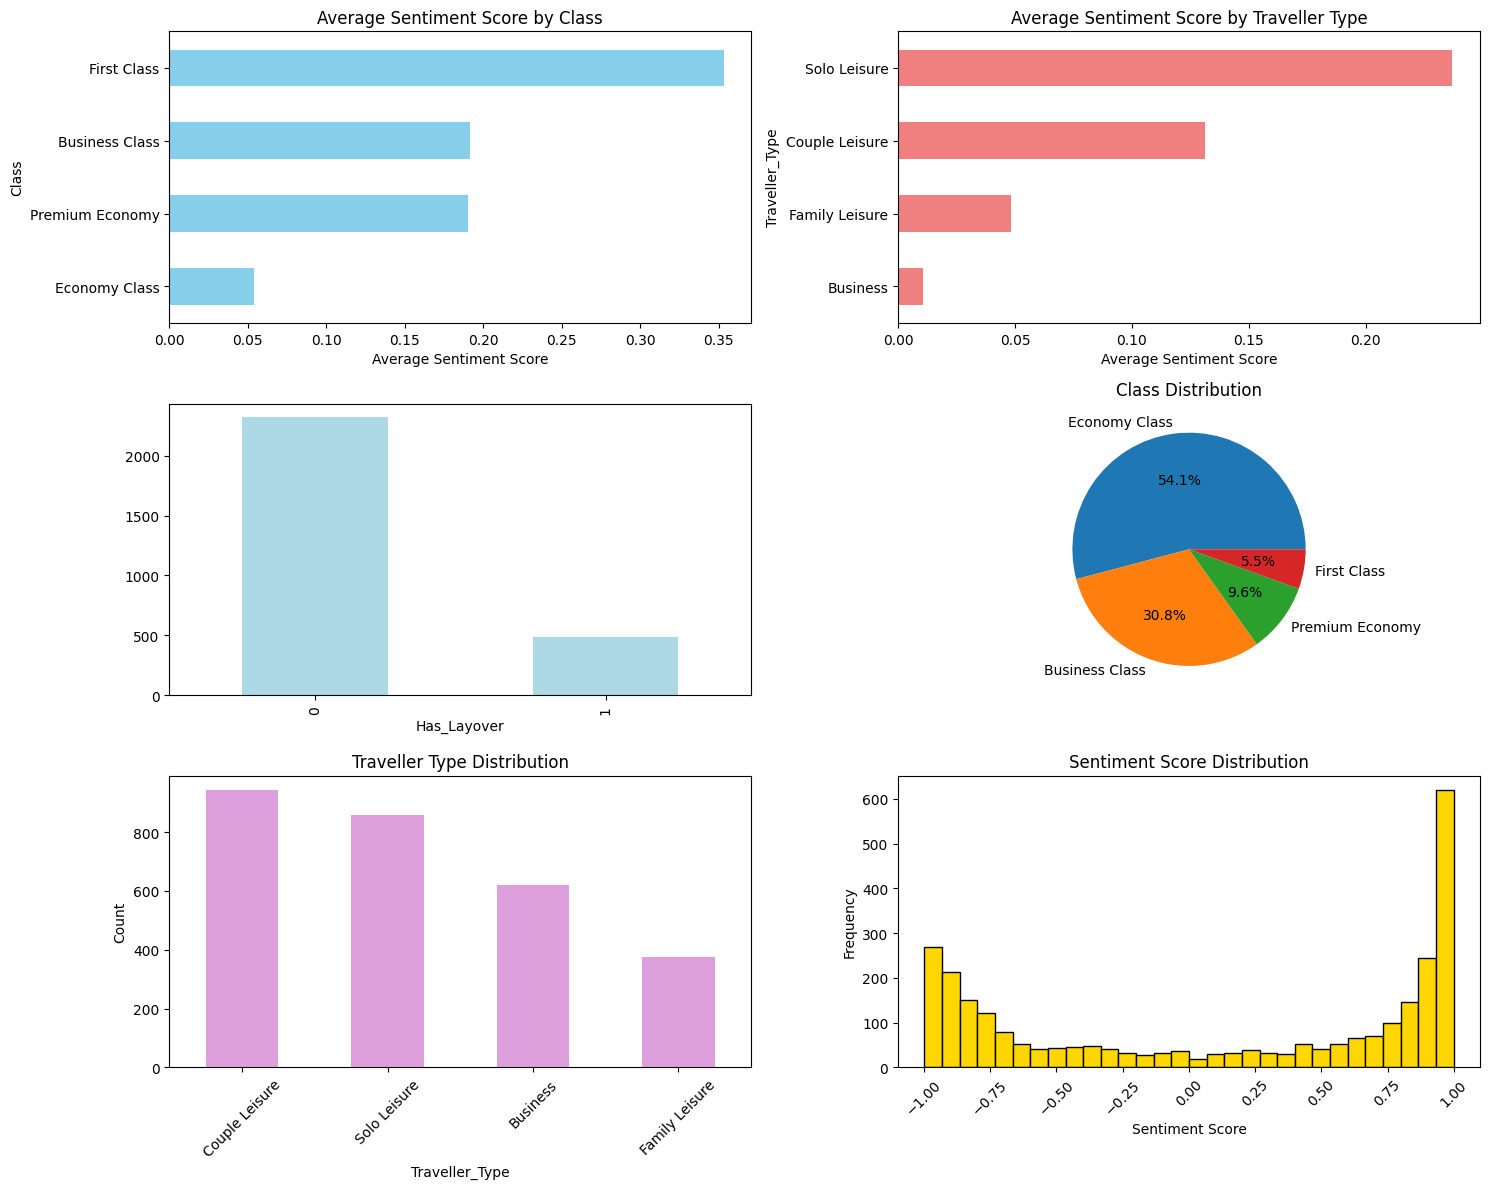

In [861]:
# Create visualizations
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# 1. Sentiment Score by Class
asr.groupby('Class')['Sentiment_Score'].mean().sort_values().plot(kind='barh', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Average Sentiment Score by Class')
axes[0, 0].set_xlabel('Average Sentiment Score')

# 2. Sentiment Score by Traveller Type
asr.groupby('Traveller_Type')['Sentiment_Score'].mean().sort_values().plot(kind='barh', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Average Sentiment Score by Traveller Type')
axes[0, 1].set_xlabel('Average Sentiment Score')

# 3. Has layover Distribution
asr['Has_Layover'].value_counts().plot(kind='bar', ax=axes[1, 0], color='lightblue')
axes[2, 1].set_title('Has Layover Distribution')
axes[2, 1].set_ylabel('Count')
axes[2, 1].tick_params(axis='x', rotation=45)

# 4. Class Distribution
asr['Class'].value_counts().plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%')
axes[1, 1].set_title('Class Distribution')
axes[1, 1].set_ylabel('')

# 5. Traveller Type Distribution
asr['Traveller_Type'].value_counts().plot(kind='bar', ax=axes[2, 0], color='plum')
axes[2, 0].set_title('Traveller Type Distribution')
axes[2, 0].set_ylabel('Count')
axes[2, 0].tick_params(axis='x', rotation=45)

# 6. Sentiment Score Distribution
axes[2, 1].hist(asr['Sentiment_Score'], bins=30, color='gold', edgecolor='black')
axes[2, 1].set_title('Sentiment Score Distribution')
axes[2, 1].set_xlabel('Sentiment Score')
axes[2, 1].set_ylabel('Frequency')





plt.tight_layout()
plt.show()

In [862]:
# Create figure for boxplots and correlation analysis
fig, axes = plt.subplots(1, 1, figsize=(16, 18))


# 2. Box plot: Sentiment Score by Has_Layover
asr.boxplot(column='Sentiment_Score', ax=axes, patch_artist=True)
axes.set_title('Sentiment Score by Has_Layover')
axes.set_xlabel('Has_Layover')
axes.set_ylabel('Sentiment Score')
plt.sca(axes)


<h1>Preprocessing</h1>

In [863]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
# For models
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import shap

In [864]:
asr['Satisfaction'] = (asr['Rating'] >= 5).astype(int)

In [865]:
label_encoder = LabelEncoder()
asr['Route_Standardized'] = label_encoder.fit_transform(asr['Route_Standardized'])

In [866]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(asr[['Class', 'Traveller_Type', 'Verified']])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['Class', 'Traveller_Type', 'Verified']))

asr = pd.concat([asr.drop(['Class', 'Traveller_Type', 'Verified'], axis=1), one_hot_df], axis=1)
asr = asr.drop(['Verified_Not Verified'], axis=1)

In [867]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2803 entries, 0 to 2802
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Passanger_Name                 2803 non-null   object 
 1   Route                          2803 non-null   object 
 2   Rating                         2803 non-null   float64
 3   Review_title                   2803 non-null   object 
 4   Review_content                 2803 non-null   object 
 5   Start_Location                 2803 non-null   object 
 6   End_Location                   2803 non-null   object 
 7   Route_Standardized             2803 non-null   int32  
 8   Has_Layover                    2803 non-null   int64  
 9   Sentiment_Score                2803 non-null   float64
 10  Satisfaction                   2803 non-null   int32  
 11  Class_Business Class           2803 non-null   float64
 12  Class_Economy Class            2803 non-null   f

<h1>Model Training</h1>

## Feature Selection and Preparation

### Selected Features:
1. **Traveller_Type**: Type of passenger (Business, Leisure, etc.)
2. **Class**: Flight class (Economy, Business, First Class)
3. **Verified**: Whether the review is verified
4. **Sentiment_Score**: Calculated sentiment from review text (VADER compound score)
5. **Has_Layover**: Whether the flight had a layover (engineered feature)
6. **Route_Standardized**: Standardized routes (City1-City2)

### Why these features?
- **Traveller-related**: Type and Class directly indicate passenger segment
- **Flight-related**: Route popularity (frequency) and layover information capture route characteristics
- **Review-related**: Verified status and sentiment provide review quality indicators

### Route Feature Engineering:
- **Standardization**: Converted all "City1 to City2" formats to "City1-City2" for consistency


In [868]:
# Select features for modeling (using Route_Frequency instead of raw Route)
feature_columns = [
    'Traveller_Type_Business', 'Traveller_Type_Family Leisure', 'Traveller_Type_Couple Leisure',  'Traveller_Type_Solo Leisure','Class_Business Class', 'Class_Economy Class', 'Class_First Class', 'Class_Premium Economy', 'Verified_Trip Verified', 'Sentiment_Score', 'Has_Layover', 'Route_Standardized'
]
X = asr[feature_columns]
y = asr['Satisfaction']
print(f"\nSelected features summary:")
print(asr[feature_columns].describe())


Selected features summary:
       Traveller_Type_Business  Traveller_Type_Family Leisure  \
count              2803.000000                    2803.000000   
mean                  0.221905                       0.134499   
std                   0.415602                       0.341248   
min                   0.000000                       0.000000   
25%                   0.000000                       0.000000   
50%                   0.000000                       0.000000   
75%                   0.000000                       0.000000   
max                   1.000000                       1.000000   

       Traveller_Type_Couple Leisure  Traveller_Type_Solo Leisure  \
count                    2803.000000                  2803.000000   
mean                        0.337139                     0.306457   
std                         0.472817                     0.461104   
min                         0.000000                     0.000000   
25%                         0.000000     

In [869]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

Training set size: 2242
Test set size: 561

Training set target distribution:
Satisfaction
0    1269
1     973
Name: count, dtype: int64

Test set target distribution:
Satisfaction
0    317
1    244
Name: count, dtype: int64


### Model 1: Random Forest Classifier

In [870]:
# Train Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Training completed!")

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("\n" + "="*60)
print("RANDOM FOREST CLASSIFIER - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Dissatisfied', 'Satisfied']))

Training Random Forest Classifier...
Training completed!

RANDOM FOREST CLASSIFIER - RESULTS

Accuracy:  0.8146
Precision: 0.7778
Recall:    0.8033
F1-Score:  0.7903

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.84      0.82      0.83       317
   Satisfied       0.78      0.80      0.79       244

    accuracy                           0.81       561
   macro avg       0.81      0.81      0.81       561
weighted avg       0.82      0.81      0.81       561




SHAP GLOBAL FEATURE IMPORTANCE - ALL FEATURES


C:\Users\ahmos\AppData\Local\Temp\ipykernel_21936\4081361550.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


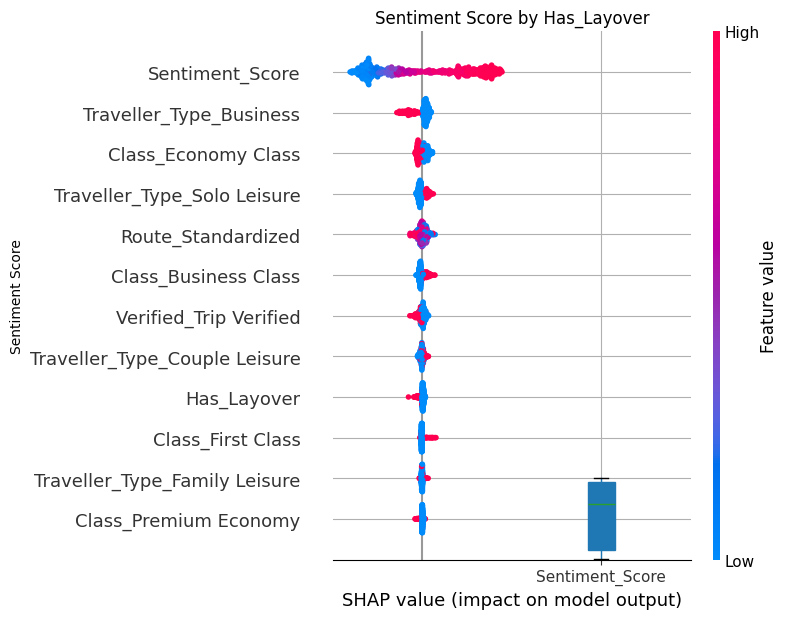

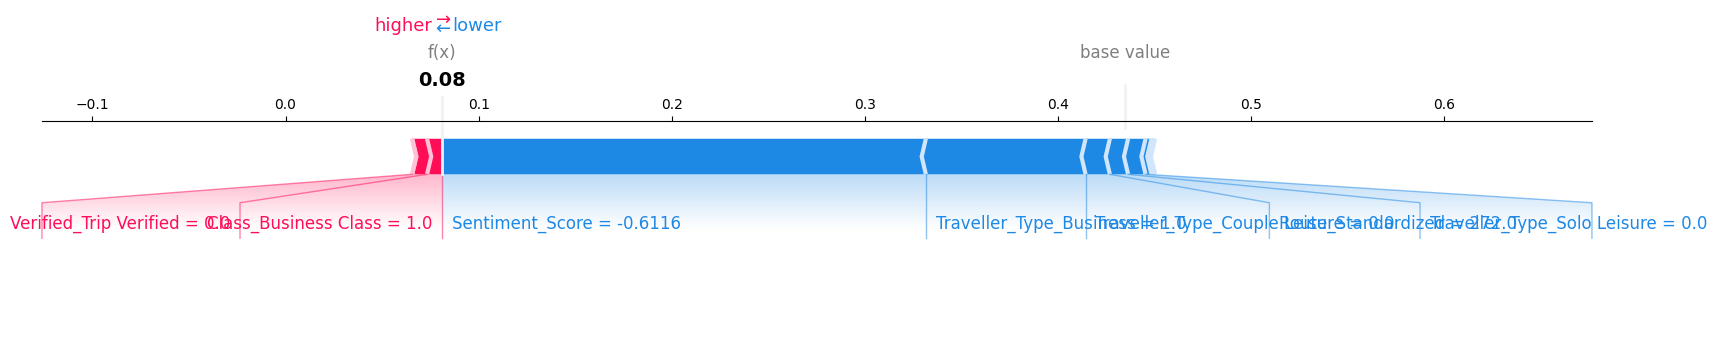

In [871]:
# SHAP Global Explainer - All Features
print("\n" + "="*70)
print("SHAP GLOBAL FEATURE IMPORTANCE - ALL FEATURES")
print("="*70)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values[:, :, 1],  # All samples, all features, Satisfied class
    X_test,
    feature_names=feature_columns
)
# LOCAL SHAP

i=0
shap_explanation = shap.Explanation(
    values=shap_values[i, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[i].values,
    feature_names=feature_columns
)

fig = shap.plots.force(shap_explanation,matplotlib=True, show=False)
plt.show()

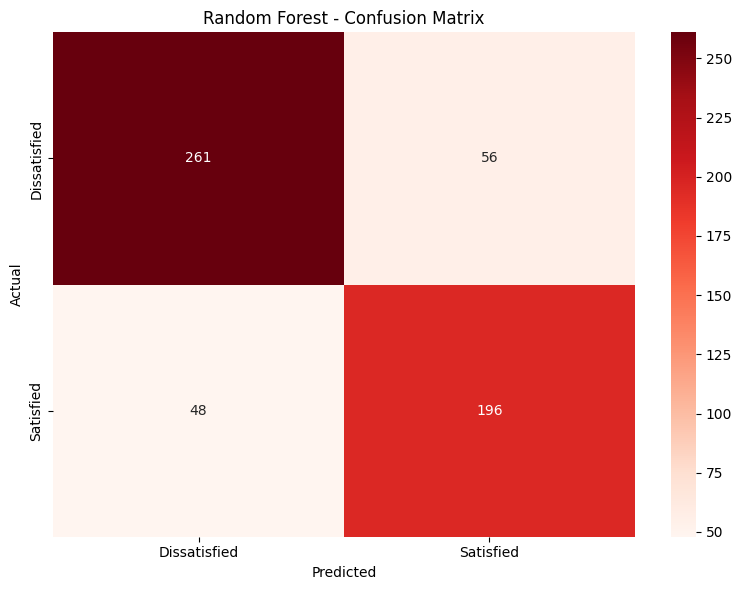

In [872]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

### Model 2: Shallow Feed-Forward Neural Network (FFNN)

In [873]:
# Scale features for neural network (important for gradient-based optimization)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Features scaled for neural network training")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")

Features scaled for neural network training
Training data shape: (2242, 12)
Test data shape: (561, 12)


In [874]:
# Build Shallow FFNN model
print("Building Shallow Feed-Forward Neural Network...")

ffnn_model = keras.Sequential([
    # Input layer
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    # First hidden layer with 64 neurons
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.3),
    
    # Second hidden layer with 32 neurons
    layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    
    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
ffnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("\nModel Architecture:")
ffnn_model.summary()

Building Shallow Feed-Forward Neural Network...

Model Architecture:


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [875]:
# Train the FFNN model
print("Training Shallow FFNN...")
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = ffnn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")

Training Shallow FFNN...
Epoch 1/100


57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6525 - loss: 0.6766 - precision_10: 0.5927 - recall_10: 0.5763 - val_accuracy: 0.8129 - val_loss: 0.5789 - val_precision_10: 0.8146 - val_recall_10: 0.7840
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7546 - loss: 0.5822 - precision_10: 0.7133 - recall_10: 0.7039 - val_accuracy: 0.8151 - val_loss: 0.5109 - val_precision_10: 0.8095 - val_recall_10: 0.7981
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7741 - loss: 0.5408 - precision_10: 0.7314 - recall_10: 0.7382 - val_accuracy: 0.8218 - val_loss: 0.4886 - val_precision_10: 0.8037 - val_recall_10: 0.8263
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7797 - loss: 0.5404 - precision_10: 0.7284 - recall_10: 0.7658 - val_accuracy: 0.8241 - val_loss: 0.4830 - val_precision_10: 0.7991 - val_recall_10: 0.8404
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7797 - loss: 0.5316 - precision_10: 0.7207 - recall_10: 0.7842 

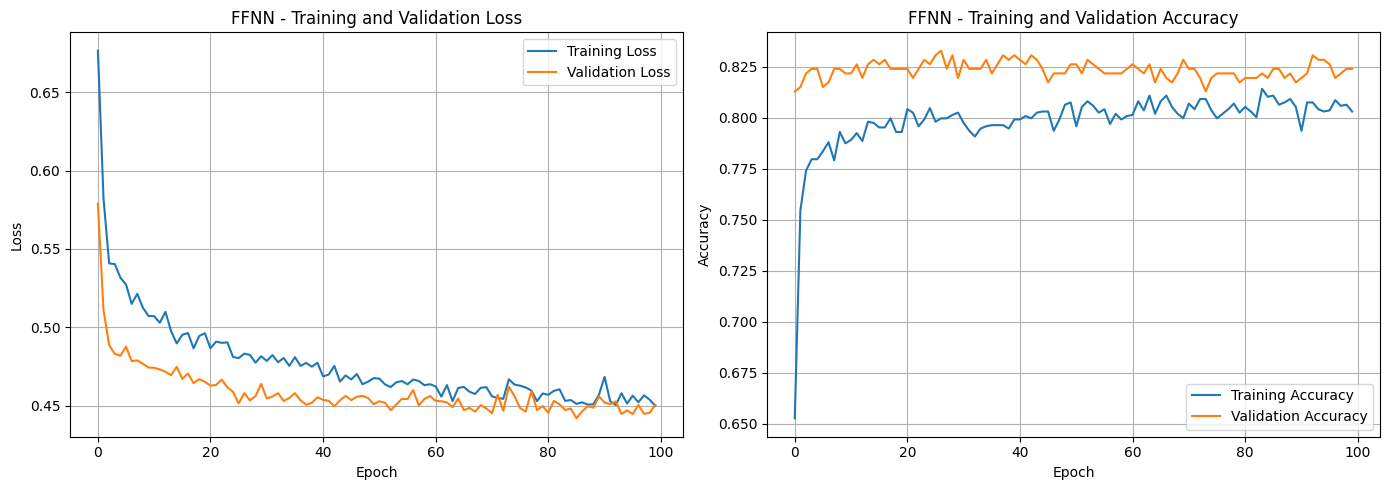

In [876]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('FFNN - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('FFNN - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [877]:
# Evaluate FFNN on test set
y_pred_ffnn_probs = ffnn_model.predict(X_test_scaled)
y_pred_ffnn = (y_pred_ffnn_probs > 0.5).astype(int).flatten()

print("="*60)
print("SHALLOW FFNN - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_ffnn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ffnn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_ffnn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_ffnn):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ffnn, target_names=['Dissatisfied', 'Satisfied']))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
SHALLOW FFNN - RESULTS

Accuracy:  0.8111
Precision: 0.7575
Recall:    0.8320
F1-Score:  0.7930

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.86      0.79      0.83       317
   Satisfied       0.76      0.83      0.79       244

    accuracy                           0.81       561
   macro avg       0.81      0.81      0.81       561
weighted avg       0.82      0.81      0.81       561



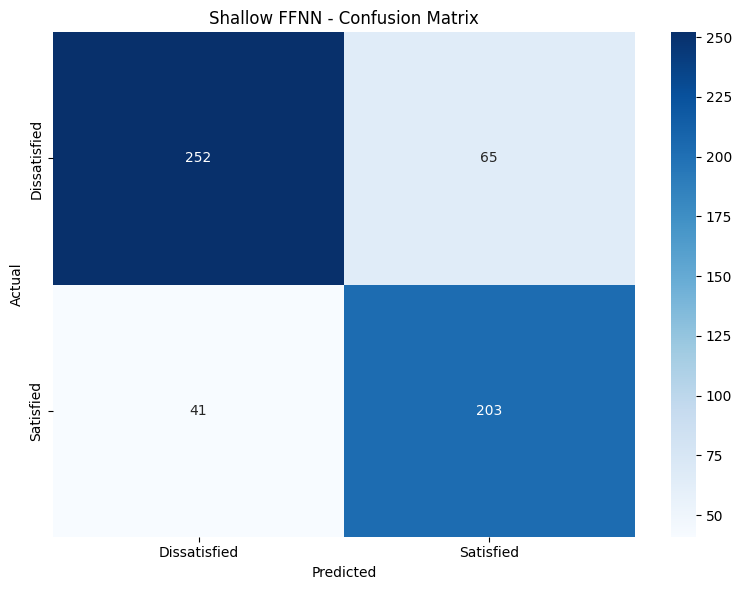

In [878]:
# Confusion Matrix for FFNN
cm_ffnn = confusion_matrix(y_test, y_pred_ffnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ffnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Shallow FFNN - Confusion Matrix')
plt.tight_layout()
plt.show()

PermutationExplainer explainer: 562it [00:37, 10.85it/s]                         
C:\Users\ahmos\AppData\Local\Temp\ipykernel_21936\3185257774.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


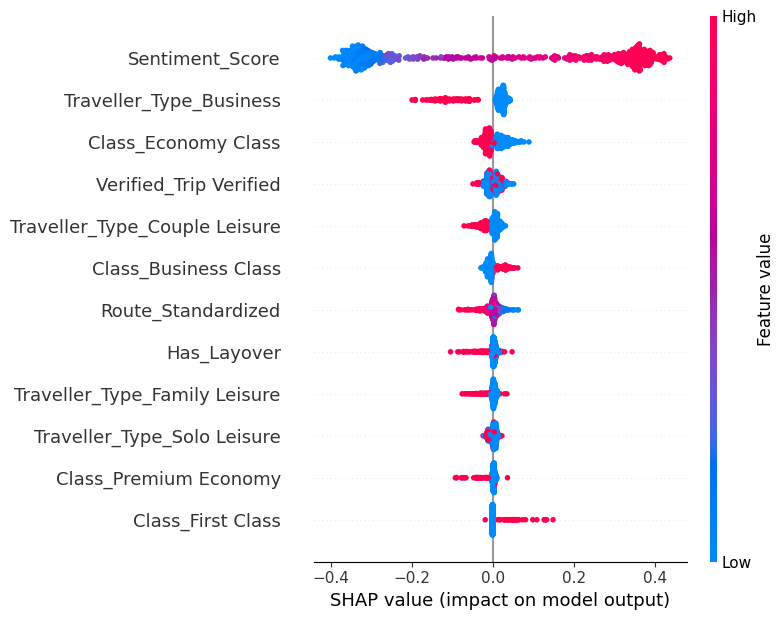

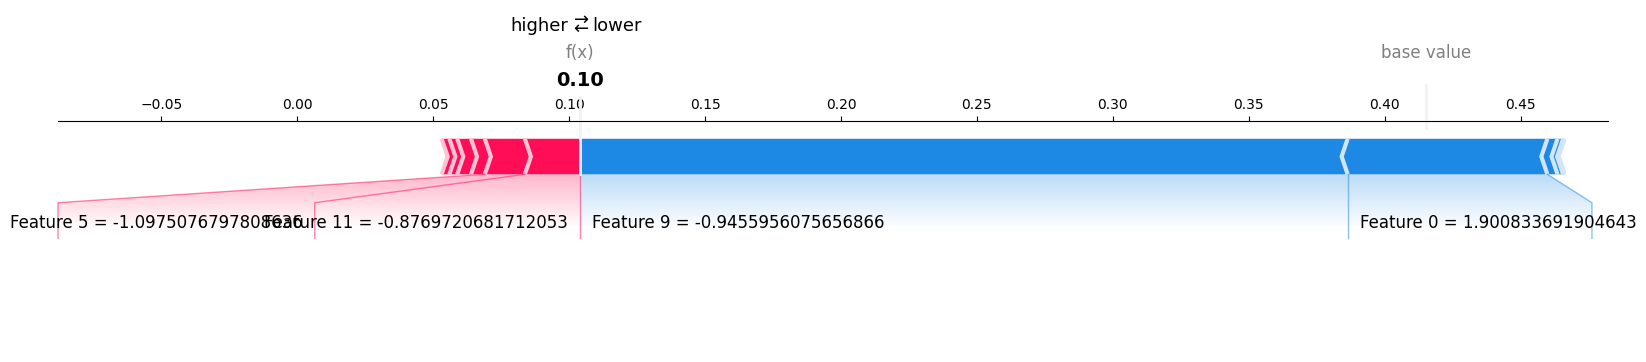

In [879]:
# Global SHAP
background = shap.sample(X_train_scaled, 100, random_state=42)
explainer = shap.Explainer(ffnn_model, background.values)
shap_values = explainer(X_test_scaled.values)

shap.summary_plot(
    shap_values.values,
    X_test_scaled,
    feature_names=feature_columns
)

# LOCAL SHAP
fig = shap.plots.force(shap_values[0], matplotlib=True, show=False)
for text in fig.findobj(plt.Text):
    text.set_color('black')

ax = plt.gca()
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')


plt.show()

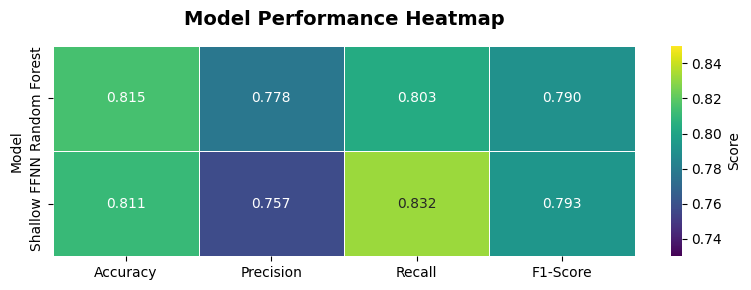

In [880]:
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Shallow FFNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ffnn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_ffnn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_ffnn)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_ffnn)
    ]
})

fig, ax = plt.subplots(figsize=(8, 3))
heatmap_data = comparison_df.set_index('Model')

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='viridis', 
            vmin=0.73, vmax=0.85, cbar_kws={'label': 'Score'},
            linewidths=0.5, ax=ax)

ax.set_title('Model Performance Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Inference Function for Neural Network

In [881]:
def predict_satisfaction(input_df, model, scaler, encoder, label_encoder, sia):
    """
    Predict satisfaction for new passenger data using the Neural Network model.
    Applies all preprocessing steps from the training pipeline.
    
    Parameters:
    -----------
    input_df : pd.DataFrame
        DataFrame with one row containing raw unprocessed data
        Required columns: ['Review_content', 'Route_Standardized', 'Class', 
                          'Traveller_Type', 'Verified', 'Has_Layover']
    model : keras.Model
        Trained FFNN model
    scaler : StandardScaler
        Fitted scaler used during training
    encoder : OneHotEncoder
        Fitted one-hot encoder for categorical features
    label_encoder : LabelEncoder
        Fitted label encoder for Route_Standardized
    sia : SentimentIntensityAnalyzer
        VADER sentiment analyzer
        
    Returns:
    --------
    dict: Prediction results with probability and class
    """
    # Create a copy to avoid modifying original
    df = input_df.copy()
    
    # Step 1: Calculate sentiment score from review content
    if 'Review_content' in df.columns:
        df['Sentiment_Score'] = df['Review_content'].apply(
            lambda x: sia.polarity_scores(str(x))['compound'] if pd.notna(x) else 0
        )
    else:
        df['Sentiment_Score'] = 0
    
    # Step 2: Clean categorical features (remove Unknown/Various if present)
    if 'Class' in df.columns:
        if df['Class'].iloc[0] in ['Unknown']:
            raise ValueError("Class cannot be 'Unknown'")
    
    if 'Traveller_Type' in df.columns:
        if df['Traveller_Type'].iloc[0] in ['Unknown', 'Various']:
            raise ValueError("Traveller_Type cannot be 'Unknown' or 'Various'")
    
    # Step 3: One-hot encode categorical features
    categorical_cols = ['Class', 'Traveller_Type', 'Verified']
    one_hot_encoded = encoder.transform(df[categorical_cols])
    one_hot_df = pd.DataFrame(
        one_hot_encoded, 
        columns=encoder.get_feature_names_out(categorical_cols),
        index=df.index
    )
    
    # Step 4: Encode Route_Standardized
    if 'Route_Standardized' in df.columns:
        try:
            df['Route_Standardized'] = label_encoder.transform(df['Route_Standardized'])
        except:
            # If route not seen during training, use most common route encoding
            df['Route_Standardized'] = 0
    
    # Step 5: Combine features in correct order
    feature_columns = [
        'Traveller_Type_Business', 'Traveller_Type_Family Leisure', 
        'Traveller_Type_Couple Leisure', 'Traveller_Type_Solo Leisure',
        'Class_Business Class', 'Class_Economy Class', 
        'Class_First Class', 'Class_Premium Economy',
        'Verified_Trip Verified',
        'Sentiment_Score', 'Has_Layover', 'Route_Standardized'
    ]
    
    # Create final feature dataframe
    final_df = pd.DataFrame(index=df.index)
    
    # Add one-hot encoded columns
    for col in one_hot_df.columns:
        final_df[col] = one_hot_df[col]
    
    # Add numerical columns
    final_df['Sentiment_Score'] = df['Sentiment_Score']
    final_df['Has_Layover'] = df['Has_Layover']
    final_df['Route_Standardized'] = df['Route_Standardized']
    
    # Ensure all feature columns exist in correct order
    final_df = final_df[feature_columns]
    
    # Step 6: Scale features
    input_scaled = scaler.transform(final_df)
    
    # Step 7: Make prediction
    probability = model.predict(input_scaled, verbose=0)[0][0]
    prediction = 1 if probability > 0.5 else 0
    
    return {
        'prediction': 'Customer will be Satisfied, Enjoy your travels!' if prediction == 1 else 'Customer will be Dissatisfied,  Need to Address their concerns!!',
        'probability': float(probability),
        'confidence': float(max(probability, 1 - probability))
    }


# Example usage
print("="*70)
print("NEURAL NETWORK INFERENCE FUNCTION")
print("="*70)

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Test with raw unprocessed sample data
sample_1 = pd.DataFrame([{
    'Review_content': 'Excellent service, very comfortable flight and friendly staff. Highly recommend!',
    'Route_Standardized': 'London-New York',
    'Class': 'Business Class',
    'Traveller_Type': 'Business',
    'Verified': 'Trip Verified',
    'Has_Layover': 0
}])

result_1 = predict_satisfaction(
    input_df=sample_1,
    model=ffnn_model,
    scaler=scaler,
    encoder=encoder,
    label_encoder=label_encoder,
    sia=sia
)

print("\nSample 1 - Positive Review:")
print(f"Review: '{sample_1['Review_content'].iloc[0][:60]}...'")
print(f"Route: {sample_1['Route_Standardized'].iloc[0]}")
print(f"Class: {sample_1['Class'].iloc[0]}, Type: {sample_1['Traveller_Type'].iloc[0]}")
print(f"\n→ Prediction: {result_1['prediction']}")
print(f"  Probability: {result_1['probability']:.4f}")
print(f"  Confidence: {result_1['confidence']:.4f}")

# Test with negative review
sample_2 = pd.DataFrame([{
    'Review_content': 'amazing experience. Flight was on time, staff was nice, and seats were comfortable.',
    'Route_Standardized': 'Paris-London',
    'Class': 'Economy Class',
    'Traveller_Type': 'Family Leisure',
    'Verified': 'Trip Verified',
    'Has_Layover': 1
}])

result_2 = predict_satisfaction(
    input_df=sample_2,
    model=ffnn_model,
    scaler=scaler,
    encoder=encoder,
    label_encoder=label_encoder,
    sia=sia
)

print("\n" + "-"*70)
print("\nSample 2 - Positive Review:")
print(f"Review: '{sample_2['Review_content'].iloc[0][:60]}...'")
print(f"Route: {sample_2['Route_Standardized'].iloc[0]}")
print(f"Class: {sample_2['Class'].iloc[0]}, Type: {sample_2['Traveller_Type'].iloc[0]}")
print(f"\n→ Prediction: {result_2['prediction']}")
print(f"  Probability: {result_2['probability']:.4f}")
print(f"  Confidence: {result_2['confidence']:.4f}")

# Test with neutral review
sample_3 = pd.DataFrame([{
    'Review_content': 'No complaints and no problems!',
    'Route_Standardized': 'Dubai-London',
    'Class': 'Premium Economy',
    'Traveller_Type': 'Solo Leisure',
    'Verified': 'Trip Verified',
    'Has_Layover': 0
}])

result_3 = predict_satisfaction(
    input_df=sample_3,
    model=ffnn_model,
    scaler=scaler,
    encoder=encoder,
    label_encoder=label_encoder,
    sia=sia
)

print("\n" + "-"*70)
print("\nSample 3 - Neutral Review:")
print(f"Review: '{sample_3['Review_content'].iloc[0][:60]}...'")
print(f"Route: {sample_3['Route_Standardized'].iloc[0]}")
print(f"Class: {sample_3['Class'].iloc[0]}, Type: {sample_3['Traveller_Type'].iloc[0]}")
print(f"\n→ Prediction: {result_3['prediction']}")
print(f"  Probability: {result_3['probability']:.4f}")
print(f"  Confidence: {result_3['confidence']:.4f}")

print("\n" + "="*70)

NEURAL NETWORK INFERENCE FUNCTION

Sample 1 - Positive Review:
Review: 'Excellent service, very comfortable flight and friendly staf...'
Route: London-New York
Class: Business Class, Type: Business

→ Prediction: Customer will be Satisfied, Enjoy your travels!
  Probability: 0.7097
  Confidence: 0.7097

----------------------------------------------------------------------

Sample 2 - Positive Review:
Review: 'amazing experience. Flight was on time, staff was nice, and ...'
Route: Paris-London
Class: Economy Class, Type: Family Leisure

→ Prediction: Customer will be Satisfied, Enjoy your travels!
  Probability: 0.7706
  Confidence: 0.7706

----------------------------------------------------------------------

Sample 3 - Neutral Review:
Review: 'No complaints and no problems!...'
Route: Dubai-London
Class: Premium Economy, Type: Solo Leisure

→ Prediction: Customer will be Dissatisfied,  Need to Address their concerns!!
  Probability: 0.0816
  Confidence: 0.9184



<h1>Second Model</h1>

In [882]:
asr = pd.read_csv(r"..\AirlineScrappedReview_Processed_StandardizedRoutes.csv")

In [883]:
asr = asr[asr['Class'] != "Unknown"].reset_index(drop=True)
asr = asr[asr['Traveller_Type'] != "Unknown"].reset_index(drop=True)
asr = asr[asr['Traveller_Type'] != "Various"].reset_index(drop=True)
asr = asr.drop(['Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude', 'Start_Address', 'End_Address', 'Layover_Route'], axis=1)

In [884]:
asr['Satisfaction'] = (asr['Rating'] >= 5).astype(int)

In [885]:
# Install and import VADER
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
print("Downloading VADER lexicon...")
nltk.download('vader_lexicon', quiet=True)
print("✅ VADER lexicon ready!")

# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores
def get_sentiment_score(text):
    """
    Calculate sentiment using VADER
    Returns compound score (-1 to +1)
    """
    try:
        sentiment_dict = sia.polarity_scores(str(text))
        return sentiment_dict['compound']
    except:
        return 0.0

print("\n" + "=" * 60)
print("STEP 3: CALCULATING SENTIMENT SCORES")
print("=" * 60)

print("\nCalculating sentiment scores using VADER...")
asr['Sentiment_Score'] = asr['Review_content'].apply(get_sentiment_score)
print("✅ Sentiment scores calculated!")

print(f"\nSentiment Score Statistics:")
print(asr['Sentiment_Score'].describe())

print(f"\nSample reviews with sentiment scores:")
sample_display = asr[['Review_content', 'Sentiment_Score', 'Rating']].head(10)
for idx, row in sample_display.iterrows():
    print(f"\nRating: {row['Rating']:.1f} | Sentiment: {row['Sentiment_Score']:.3f}")
    print(f"Review: {row['Review_content'][:100]}...")# Install and import VADER
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
print("Downloading VADER lexicon...")
nltk.download('vader_lexicon', quiet=True)
print("✅ VADER lexicon ready!")

# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores
def get_sentiment_score(text):
    """
    Calculate sentiment using VADER
    Returns compound score (-1 to +1)
    """
    try:
        sentiment_dict = sia.polarity_scores(str(text))
        return sentiment_dict['compound']
    except:
        return 0.0

print("\n" + "=" * 60)
print("STEP 3: CALCULATING SENTIMENT SCORES")
print("=" * 60)

print("\nCalculating sentiment scores using VADER...")
asr['Sentiment_Score'] = asr['Review_content'].apply(get_sentiment_score)
print("✅ Sentiment scores calculated!")

print(f"\nSentiment Score Statistics:")
print(asr['Sentiment_Score'].describe())

✅ VADER lexicon ready!

STEP 3: CALCULATING SENTIMENT SCORES

Calculating sentiment scores using VADER...
✅ Sentiment scores calculated!

Sentiment Score Statistics:
count    2803.000000
mean        0.125699
std         0.781678
min        -0.997400
25%        -0.765000
50%         0.362600
75%         0.918600
max         0.999200
Name: Sentiment_Score, dtype: float64

Sample reviews with sentiment scores:

Rating: 1.0 | Sentiment: -0.799
Review: The airline lost my luggage and was absolutely awful throughout the entire trip. They gave me no upd...

Rating: 1.0 | Sentiment: 0.718
Review: We booked on the BA website, round trip flights from Seattle to Amman with a stop in London, in Busi...

Rating: 2.0 | Sentiment: -0.710
Review: First time flying with BA business class, never again. There are no boarding drinks provided. My mea...

Rating: 4.0 | Sentiment: -0.585
Review: You can buy sandwiches and crisps but don't expect a hot meal. Because the plane is a narrow body , ...

Rating: 7

In [886]:
label_encoder = LabelEncoder()
asr['Route_Standardized'] = label_encoder.fit_transform(asr['Route_Standardized'])
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(asr[['Class', 'Traveller_Type', 'Verified']])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['Class', 'Traveller_Type', 'Verified']))

asr = pd.concat([asr.drop(['Class', 'Traveller_Type', 'Verified'], axis=1), one_hot_df], axis=1)
asr = asr.drop(['Verified_Not Verified'], axis=1)

In [887]:
# Select features for modeling (using Route_Frequency instead of raw Route)
feature_columns = [
    'Traveller_Type_Business', 'Traveller_Type_Family Leisure', 'Traveller_Type_Couple Leisure',  'Traveller_Type_Solo Leisure','Class_Business Class', 'Class_Economy Class', 'Class_First Class', 'Class_Premium Economy', 'Verified_Trip Verified', 'Sentiment_Score', 'Has_Layover' 
]
X = asr[feature_columns]
y = asr['Satisfaction']
print(f"\nSelected features summary:")
print(asr[feature_columns].describe())


Selected features summary:
       Traveller_Type_Business  Traveller_Type_Family Leisure  \
count              2803.000000                    2803.000000   
mean                  0.221905                       0.134499   
std                   0.415602                       0.341248   
min                   0.000000                       0.000000   
25%                   0.000000                       0.000000   
50%                   0.000000                       0.000000   
75%                   0.000000                       0.000000   
max                   1.000000                       1.000000   

       Traveller_Type_Couple Leisure  Traveller_Type_Solo Leisure  \
count                    2803.000000                  2803.000000   
mean                        0.337139                     0.306457   
std                         0.472817                     0.461104   
min                         0.000000                     0.000000   
25%                         0.000000     

In [888]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

Training set size: 2242
Test set size: 561

Training set target distribution:
Satisfaction
0    1269
1     973
Name: count, dtype: int64

Test set target distribution:
Satisfaction
0    317
1    244
Name: count, dtype: int64


In [889]:
# Train Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Training completed!")

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("\n" + "="*60)
print("RANDOM FOREST CLASSIFIER - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Dissatisfied', 'Satisfied']))

Training Random Forest Classifier...
Training completed!

RANDOM FOREST CLASSIFIER - RESULTS

Accuracy:  0.8146
Precision: 0.7823
Recall:    0.7951
F1-Score:  0.7886

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.84      0.83      0.83       317
   Satisfied       0.78      0.80      0.79       244

    accuracy                           0.81       561
   macro avg       0.81      0.81      0.81       561
weighted avg       0.82      0.81      0.81       561




SHAP GLOBAL FEATURE IMPORTANCE - ALL FEATURES


C:\Users\ahmos\AppData\Local\Temp\ipykernel_21936\4081361550.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


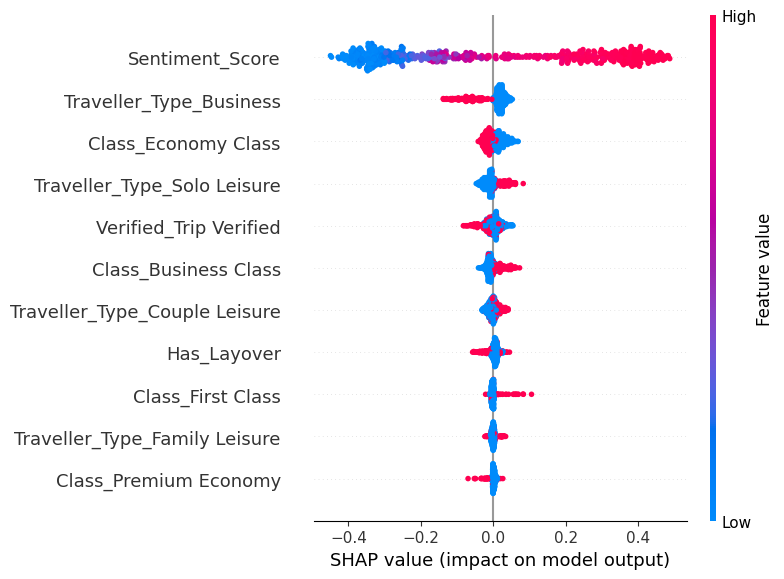

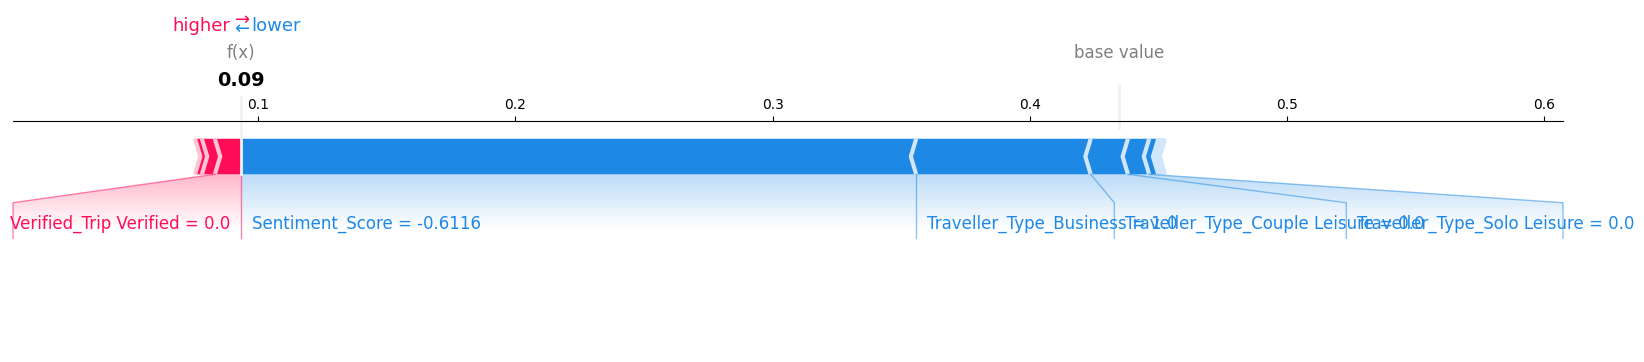

In [890]:
# SHAP Global Explainer - All Features
print("\n" + "="*70)
print("SHAP GLOBAL FEATURE IMPORTANCE - ALL FEATURES")
print("="*70)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values[:, :, 1],  # All samples, all features, Satisfied class
    X_test,
    feature_names=feature_columns
)
# LOCAL SHAP

i=0
shap_explanation = shap.Explanation(
    values=shap_values[i, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[i].values,
    feature_names=feature_columns
)

fig = shap.plots.force(shap_explanation,matplotlib=True, show=False)
plt.show()

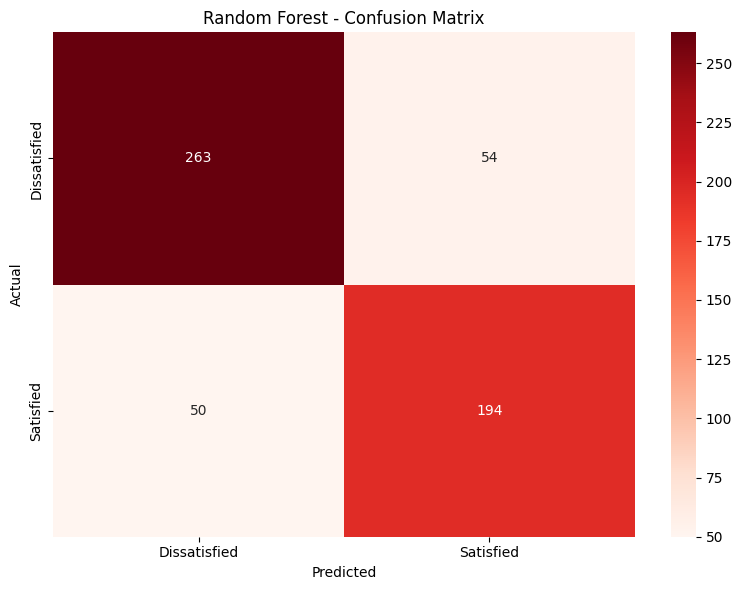

In [891]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

In [892]:
# Scale features for neural network (important for gradient-based optimization)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Features scaled for neural network training")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")

Features scaled for neural network training
Training data shape: (2242, 11)
Test data shape: (561, 11)


In [893]:
# Build Shallow FFNN model
print("Building Shallow Feed-Forward Neural Network...")

ffnn_model = keras.Sequential([
    # Input layer
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    # First hidden layer with 64 neurons
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.3),
    
    # Second hidden layer with 32 neurons
    layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    
    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
ffnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("\nModel Architecture:")
ffnn_model.summary()

Building Shallow Feed-Forward Neural Network...

Model Architecture:


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [894]:
# Train the FFNN model
print("Training Shallow FFNN...")
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = ffnn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")

Training Shallow FFNN...
Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6721 - loss: 0.6751 - precision_11: 0.6361 - recall_11: 0.5289 - val_accuracy: 0.7773 - val_loss: 0.5910 - val_precision_11: 0.7989 - val_recall_11: 0.7089
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7663 - loss: 0.5849 - precision_11: 0.7246 - recall_11: 0.7237 - val_accuracy: 0.7973 - val_loss: 0.5227 - val_precision_11: 0.7850 - val_recall_11: 0.7887
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7808 - loss: 0.5463 - precision_11: 0.7246 - recall_11: 0.7789 - val_accuracy: 0.8062 - val_loss: 0.5034 - val_precision_11: 0.7890 - val_recall_11: 0.8075
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7730 - loss: 0.5502 - precision_11: 0.7220 - recall_11: 0.7553 - val_accuracy: 0.8107 - val_loss: 0.5053 - val_precision_11: 0.7936 - val_recall_11: 0.8122
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7853 - loss: 0.5282 - prec

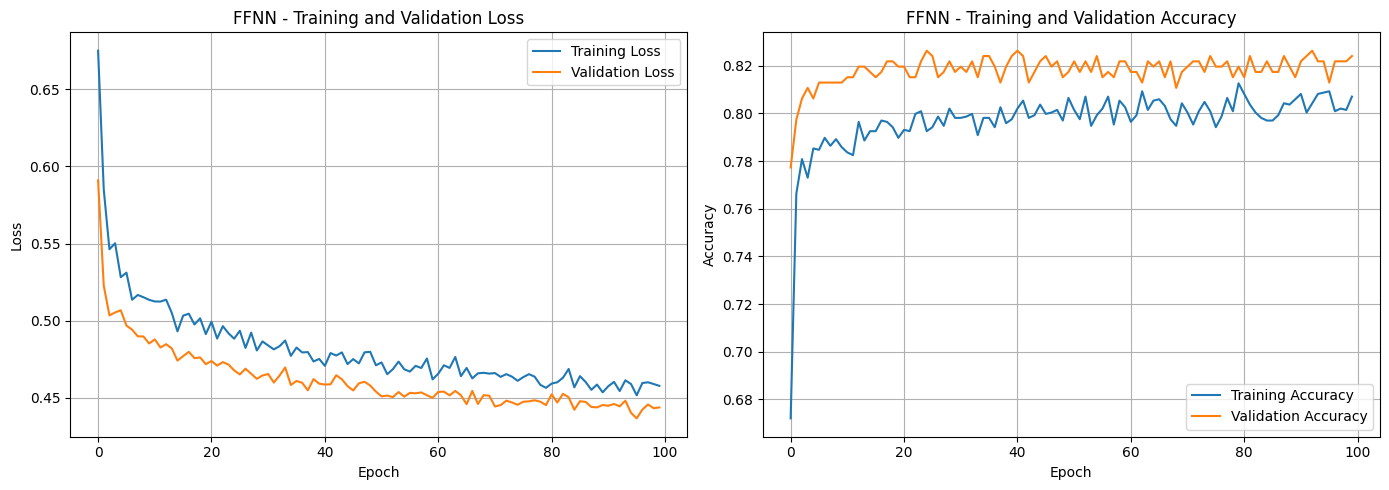

In [895]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('FFNN - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('FFNN - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [896]:
# Evaluate FFNN on test set
y_pred_ffnn_probs = ffnn_model.predict(X_test_scaled)
y_pred_ffnn = (y_pred_ffnn_probs > 0.5).astype(int).flatten()

print("="*60)
print("SHALLOW FFNN - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_ffnn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ffnn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_ffnn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_ffnn):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ffnn, target_names=['Dissatisfied', 'Satisfied']))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
SHALLOW FFNN - RESULTS

Accuracy:  0.8164
Precision: 0.7681
Recall:    0.8279
F1-Score:  0.7968

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.86      0.81      0.83       317
   Satisfied       0.77      0.83      0.80       244

    accuracy                           0.82       561
   macro avg       0.81      0.82      0.81       561
weighted avg       0.82      0.82      0.82       561



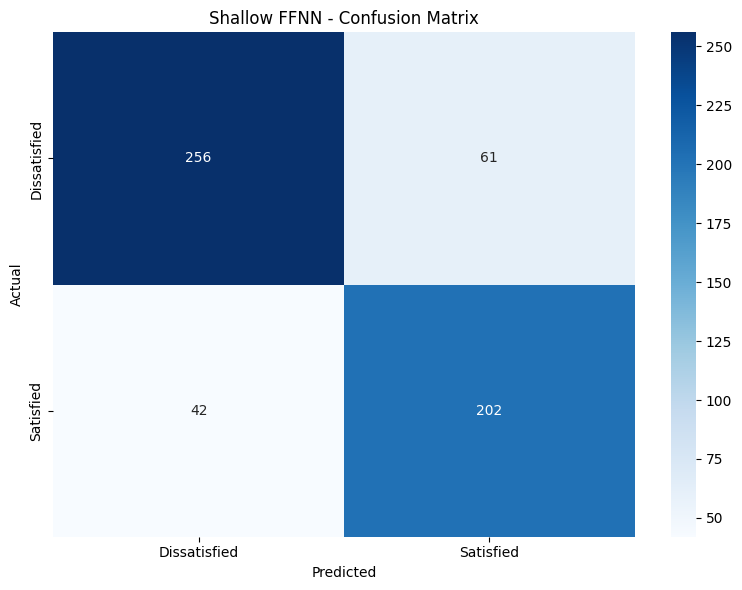

In [897]:
# Confusion Matrix for FFNN
cm_ffnn = confusion_matrix(y_test, y_pred_ffnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ffnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Shallow FFNN - Confusion Matrix')
plt.tight_layout()
plt.show()

PermutationExplainer explainer: 562it [00:38, 10.76it/s]                         
C:\Users\ahmos\AppData\Local\Temp\ipykernel_21936\3185257774.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


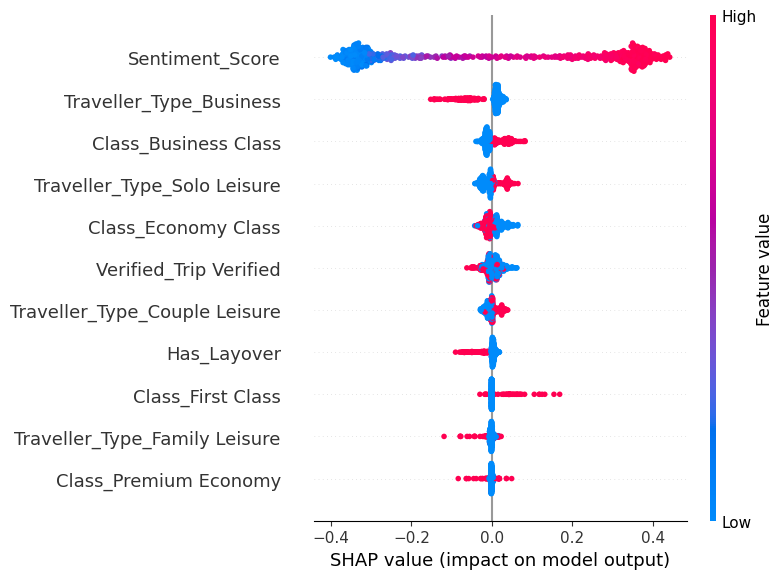

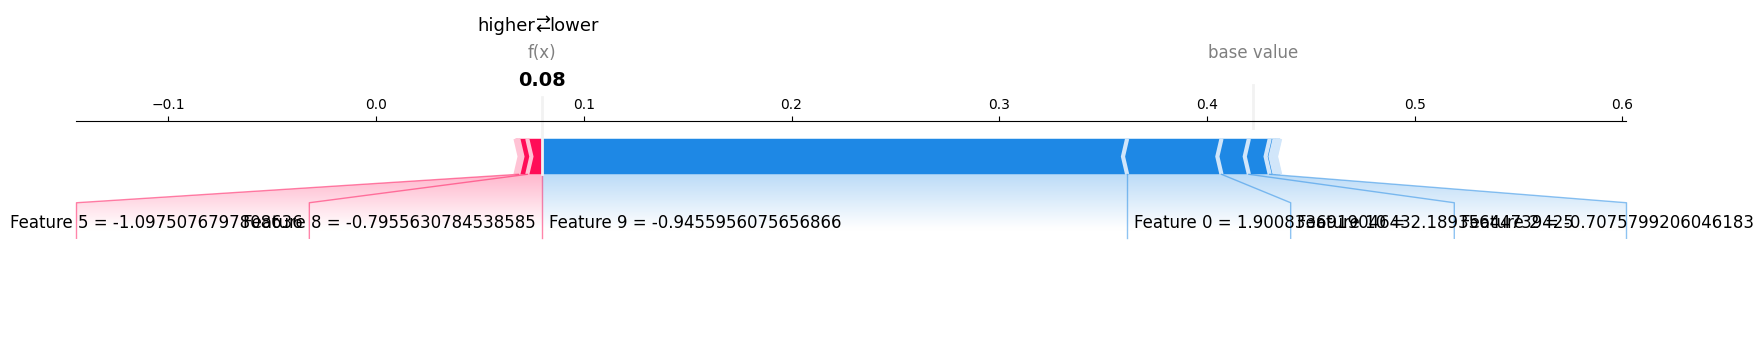

In [898]:
# Global SHAP
background = shap.sample(X_train_scaled, 100, random_state=42)
explainer = shap.Explainer(ffnn_model, background.values)
shap_values = explainer(X_test_scaled.values)

shap.summary_plot(
    shap_values.values,
    X_test_scaled,
    feature_names=feature_columns
)

# LOCAL SHAP
fig = shap.plots.force(shap_values[0], matplotlib=True, show=False)
for text in fig.findobj(plt.Text):
    text.set_color('black')

ax = plt.gca()
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')


plt.show()

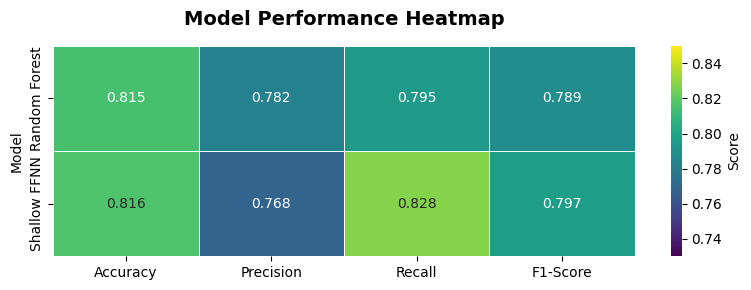

In [899]:
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Shallow FFNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ffnn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_ffnn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_ffnn)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_ffnn)
    ]
})

fig, ax = plt.subplots(figsize=(8, 3))
heatmap_data = comparison_df.set_index('Model')

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='viridis', 
            vmin=0.73, vmax=0.85, cbar_kws={'label': 'Score'},
            linewidths=0.5, ax=ax)

ax.set_title('Model Performance Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [900]:
def predict_satisfaction(input_df, model, scaler, encoder, sia):
    """
    Predict satisfaction for new passenger data using the Neural Network model.
    Applies all preprocessing steps from the training pipeline.
    
    Parameters:
    -----------
    input_df : pd.DataFrame
        DataFrame with one row containing raw unprocessed data
        Required columns: ['Review_content', 'Class', 
                          'Traveller_Type', 'Verified', 'Has_Layover']
    model : keras.Model
        Trained FFNN model
    scaler : StandardScaler
        Fitted scaler used during training
    encoder : OneHotEncoder
        Fitted one-hot encoder for categorical features
    sia : SentimentIntensityAnalyzer
        VADER sentiment analyzer
        
    Returns:
    --------
    dict: Prediction results with probability and class
    """
    # Create a copy to avoid modifying original
    df = input_df.copy()
    
    # Step 1: Calculate sentiment score from review content
    if 'Review_content' in df.columns:
        df['Sentiment_Score'] = df['Review_content'].apply(
            lambda x: sia.polarity_scores(str(x))['compound'] if pd.notna(x) else 0
        )
    else:
        df['Sentiment_Score'] = 0
    
    # Step 2: Clean categorical features (remove Unknown/Various if present)
    if 'Class' in df.columns:
        if df['Class'].iloc[0] in ['Unknown']:
            raise ValueError("Class cannot be 'Unknown'")
    
    if 'Traveller_Type' in df.columns:
        if df['Traveller_Type'].iloc[0] in ['Unknown', 'Various']:
            raise ValueError("Traveller_Type cannot be 'Unknown' or 'Various'")
    
    # Step 3: One-hot encode categorical features
    categorical_cols = ['Class', 'Traveller_Type', 'Verified']
    one_hot_encoded = encoder.transform(df[categorical_cols])
    one_hot_df = pd.DataFrame(
        one_hot_encoded, 
        columns=encoder.get_feature_names_out(categorical_cols),
        index=df.index
    )
    
    # Step 4: Combine features in correct order
    feature_columns = [
        'Traveller_Type_Business', 'Traveller_Type_Family Leisure', 
        'Traveller_Type_Couple Leisure', 'Traveller_Type_Solo Leisure',
        'Class_Business Class', 'Class_Economy Class', 
        'Class_First Class', 'Class_Premium Economy',
        'Verified_Trip Verified',
        'Sentiment_Score', 'Has_Layover'
    ]
    
    # Create final feature dataframe
    final_df = pd.DataFrame(index=df.index)
    
    # Add one-hot encoded columns
    for col in one_hot_df.columns:
        final_df[col] = one_hot_df[col]
    
    # Add numerical columns
    final_df['Sentiment_Score'] = df['Sentiment_Score']
    final_df['Has_Layover'] = df['Has_Layover']
    
    # Ensure all feature columns exist in correct order
    final_df = final_df[feature_columns]
    
    # Step 6: Scale features
    input_scaled = scaler.transform(final_df)
    
    # Step 7: Make prediction
    probability = model.predict(input_scaled, verbose=0)[0][0]
    prediction = 1 if probability > 0.5 else 0
    
    return {
        'prediction': 'Customer will be Satisfied, Enjoy your travels!' if prediction == 1 else 'Customer will be Dissatisfied,  Need to Address their concerns!!',
        'probability': float(probability),
        'confidence': float(max(probability, 1 - probability))
    }


# Example usage
print("="*70)
print("NEURAL NETWORK INFERENCE FUNCTION")
print("="*70)

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Test with raw unprocessed sample data
sample_1 = pd.DataFrame([{
    'Review_content': 'Excellent service, very comfortable flight and friendly staff. Highly recommend!',
    'Class': 'Business Class',
    'Traveller_Type': 'Business',
    'Verified': 'Trip Verified',
    'Has_Layover': 0
}])

result_1 = predict_satisfaction(
    input_df=sample_1,
    model=ffnn_model,
    scaler=scaler,
    encoder=encoder,
    sia=sia
)

print("\nSample 1 - Positive Review:")
print(f"Review: '{sample_1['Review_content'].iloc[0][:60]}...'")
print(f"Class: {sample_1['Class'].iloc[0]}, Type: {sample_1['Traveller_Type'].iloc[0]}")
print(f"\n→ Prediction: {result_1['prediction']}")
print(f"  Probability: {result_1['probability']:.4f}")
print(f"  Confidence: {result_1['confidence']:.4f}")

# Test with negative review
sample_2 = pd.DataFrame([{
    'Review_content': 'amazing experience. Flight was on time, staff was nice, and seats were comfortable.',
    'Class': 'Economy Class',
    'Traveller_Type': 'Family Leisure',
    'Verified': 'Trip Verified',
    'Has_Layover': 1
}])

result_2 = predict_satisfaction(
    input_df=sample_2,
    model=ffnn_model,
    scaler=scaler,
    encoder=encoder,
    sia=sia
)

print("\n" + "-"*70)
print("\nSample 2 - Positive Review:")
print(f"Review: '{sample_2['Review_content'].iloc[0][:60]}...'")
print(f"Class: {sample_2['Class'].iloc[0]}, Type: {sample_2['Traveller_Type'].iloc[0]}")
print(f"\n→ Prediction: {result_2['prediction']}")
print(f"  Probability: {result_2['probability']:.4f}")
print(f"  Confidence: {result_2['confidence']:.4f}")

# Test with neutral review
sample_3 = pd.DataFrame([{
    'Review_content': 'No complaints and no problems!',
    'Class': 'Premium Economy',
    'Traveller_Type': 'Solo Leisure',
    'Verified': 'Trip Verified',
    'Has_Layover': 0
}])

result_3 = predict_satisfaction(
    input_df=sample_3,
    model=ffnn_model,
    scaler=scaler,
    encoder=encoder,
    sia=sia
)

print("\n" + "-"*70)
print("\nSample 3 - Neutral Review:")
print(f"Review: '{sample_3['Review_content'].iloc[0][:60]}...'")
print(f"Class: {sample_3['Class'].iloc[0]}, Type: {sample_3['Traveller_Type'].iloc[0]}")
print(f"\n→ Prediction: {result_3['prediction']}")
print(f"  Probability: {result_3['probability']:.4f}")
print(f"  Confidence: {result_3['confidence']:.4f}")

print("\n" + "="*70)

NEURAL NETWORK INFERENCE FUNCTION

Sample 1 - Positive Review:
Review: 'Excellent service, very comfortable flight and friendly staf...'
Class: Business Class, Type: Business

→ Prediction: Customer will be Satisfied, Enjoy your travels!
  Probability: 0.6619
  Confidence: 0.6619

----------------------------------------------------------------------

Sample 2 - Positive Review:
Review: 'amazing experience. Flight was on time, staff was nice, and ...'
Class: Economy Class, Type: Family Leisure

→ Prediction: Customer will be Satisfied, Enjoy your travels!
  Probability: 0.8156
  Confidence: 0.8156

----------------------------------------------------------------------

Sample 3 - Neutral Review:
Review: 'No complaints and no problems!...'
Class: Premium Economy, Type: Solo Leisure

→ Prediction: Customer will be Dissatisfied,  Need to Address their concerns!!
  Probability: 0.1048
  Confidence: 0.8952



<h1>Third Model</h1>

In [901]:
asr = pd.read_csv(r"..\AirlineScrappedReview_Processed_StandardizedRoutes.csv")

In [902]:
asr = asr[asr['Class'] != "Unknown"].reset_index(drop=True)
asr = asr[asr['Traveller_Type'] != "Unknown"].reset_index(drop=True)
asr = asr[asr['Traveller_Type'] != "Various"].reset_index(drop=True)
asr = asr.drop(['Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude', 'Start_Address', 'End_Address', 'Layover_Route'], axis=1)

In [903]:
asr['Satisfaction'] = (asr['Rating'] >= 5).astype(int)

In [904]:
# Install and import VADER
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
print("Downloading VADER lexicon...")
nltk.download('vader_lexicon', quiet=True)
print("✅ VADER lexicon ready!")

# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores
def get_sentiment_score(text):
    """
    Calculate sentiment using VADER
    Returns compound score (-1 to +1)
    """
    try:
        sentiment_dict = sia.polarity_scores(str(text))
        return sentiment_dict['compound']
    except:
        return 0.0

print("\n" + "=" * 60)
print("STEP 3: CALCULATING SENTIMENT SCORES")
print("=" * 60)

print("\nCalculating sentiment scores using VADER...")
asr['Sentiment_Score'] = asr['Review_content'].apply(get_sentiment_score)
print("✅ Sentiment scores calculated!")

print(f"\nSentiment Score Statistics:")
print(asr['Sentiment_Score'].describe())

print(f"\nSample reviews with sentiment scores:")
sample_display = asr[['Review_content', 'Sentiment_Score', 'Rating']].head(10)
for idx, row in sample_display.iterrows():
    print(f"\nRating: {row['Rating']:.1f} | Sentiment: {row['Sentiment_Score']:.3f}")
    print(f"Review: {row['Review_content'][:100]}...")# Install and import VADER
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
print("Downloading VADER lexicon...")
nltk.download('vader_lexicon', quiet=True)
print("✅ VADER lexicon ready!")

# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores
def get_sentiment_score(text):
    """
    Calculate sentiment using VADER
    Returns compound score (-1 to +1)
    """
    try:
        sentiment_dict = sia.polarity_scores(str(text))
        return sentiment_dict['compound']
    except:
        return 0.0

print("\n" + "=" * 60)
print("STEP 3: CALCULATING SENTIMENT SCORES")
print("=" * 60)

print("\nCalculating sentiment scores using VADER...")
asr['Sentiment_Score'] = asr['Review_content'].apply(get_sentiment_score)
print("✅ Sentiment scores calculated!")

print(f"\nSentiment Score Statistics:")
print(asr['Sentiment_Score'].describe())

✅ VADER lexicon ready!

STEP 3: CALCULATING SENTIMENT SCORES

Calculating sentiment scores using VADER...
✅ Sentiment scores calculated!

Sentiment Score Statistics:
count    2803.000000
mean        0.125699
std         0.781678
min        -0.997400
25%        -0.765000
50%         0.362600
75%         0.918600
max         0.999200
Name: Sentiment_Score, dtype: float64

Sample reviews with sentiment scores:

Rating: 1.0 | Sentiment: -0.799
Review: The airline lost my luggage and was absolutely awful throughout the entire trip. They gave me no upd...

Rating: 1.0 | Sentiment: 0.718
Review: We booked on the BA website, round trip flights from Seattle to Amman with a stop in London, in Busi...

Rating: 2.0 | Sentiment: -0.710
Review: First time flying with BA business class, never again. There are no boarding drinks provided. My mea...

Rating: 4.0 | Sentiment: -0.585
Review: You can buy sandwiches and crisps but don't expect a hot meal. Because the plane is a narrow body , ...

Rating: 7

In [905]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(asr[['Class', 'Traveller_Type', 'Verified']])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['Class', 'Traveller_Type', 'Verified']))
label_encoder = LabelEncoder()
asr['Route_Standardized'] = label_encoder.fit_transform(asr['Route_Standardized'])
asr = pd.concat([asr.drop(['Class', 'Traveller_Type', 'Verified'], axis=1), one_hot_df], axis=1)
asr = asr.drop(['Verified_Not Verified'], axis=1)

In [906]:
# Select features for modeling (using Route_Frequency instead of raw Route)
feature_columns = [
    'Traveller_Type_Business', 'Traveller_Type_Family Leisure', 'Traveller_Type_Couple Leisure',  'Traveller_Type_Solo Leisure','Class_Business Class', 'Class_Economy Class', 'Class_First Class', 'Class_Premium Economy', 'Verified_Trip Verified', 'Sentiment_Score', 'Has_Layover', 'Route_Standardized'
]
X = asr[feature_columns]
y = asr['Satisfaction']
print(f"\nSelected features summary:")
print(asr[feature_columns].describe())


Selected features summary:
       Traveller_Type_Business  Traveller_Type_Family Leisure  \
count              2803.000000                    2803.000000   
mean                  0.221905                       0.134499   
std                   0.415602                       0.341248   
min                   0.000000                       0.000000   
25%                   0.000000                       0.000000   
50%                   0.000000                       0.000000   
75%                   0.000000                       0.000000   
max                   1.000000                       1.000000   

       Traveller_Type_Couple Leisure  Traveller_Type_Solo Leisure  \
count                    2803.000000                  2803.000000   
mean                        0.337139                     0.306457   
std                         0.472817                     0.461104   
min                         0.000000                     0.000000   
25%                         0.000000     

In [907]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

Training set size: 2242
Test set size: 561

Training set target distribution:
Satisfaction
0    1269
1     973
Name: count, dtype: int64

Test set target distribution:
Satisfaction
0    317
1    244
Name: count, dtype: int64


In [908]:
# Train Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Training completed!")

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("\n" + "="*60)
print("RANDOM FOREST CLASSIFIER - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Dissatisfied', 'Satisfied']))

Training Random Forest Classifier...
Training completed!

RANDOM FOREST CLASSIFIER - RESULTS

Accuracy:  0.8146
Precision: 0.7778
Recall:    0.8033
F1-Score:  0.7903

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.84      0.82      0.83       317
   Satisfied       0.78      0.80      0.79       244

    accuracy                           0.81       561
   macro avg       0.81      0.81      0.81       561
weighted avg       0.82      0.81      0.81       561




SHAP GLOBAL FEATURE IMPORTANCE - ALL FEATURES


C:\Users\ahmos\AppData\Local\Temp\ipykernel_21936\4081361550.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


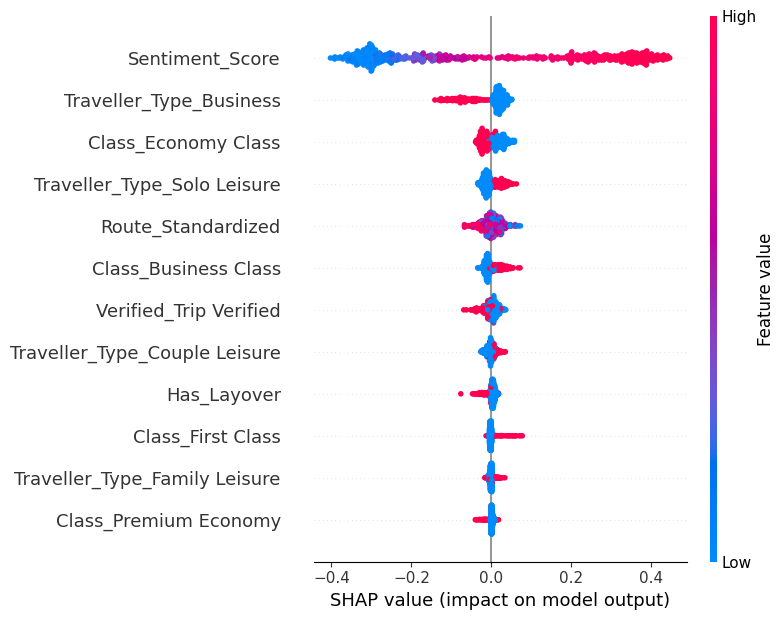

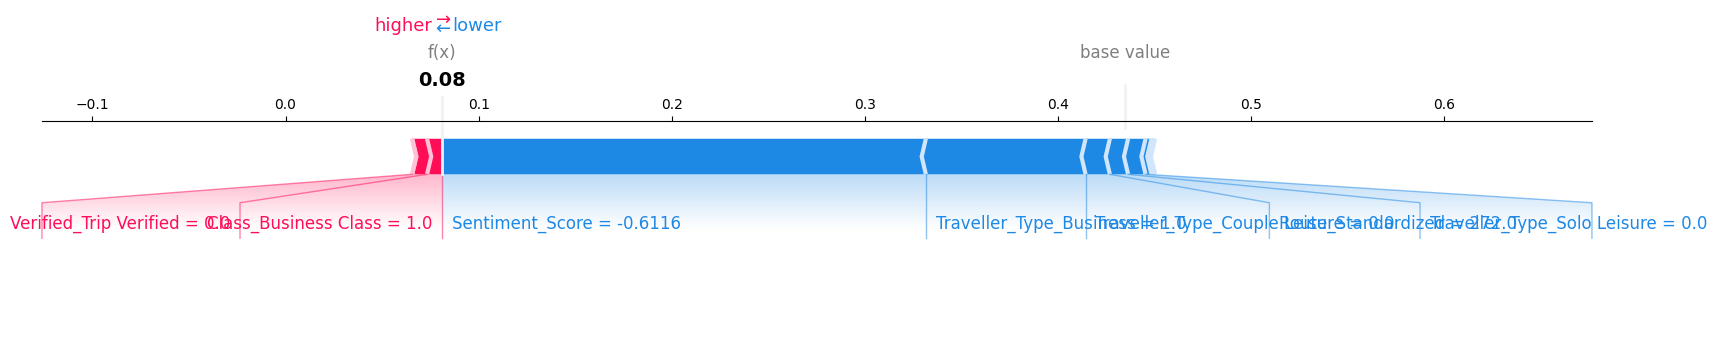

In [909]:
# SHAP Global Explainer - All Features
print("\n" + "="*70)
print("SHAP GLOBAL FEATURE IMPORTANCE - ALL FEATURES")
print("="*70)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values[:, :, 1],  # All samples, all features, Satisfied class
    X_test,
    feature_names=feature_columns
)
# LOCAL SHAP

i=0
shap_explanation = shap.Explanation(
    values=shap_values[i, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[i].values,
    feature_names=feature_columns
)

fig = shap.plots.force(shap_explanation,matplotlib=True, show=False)
plt.show()

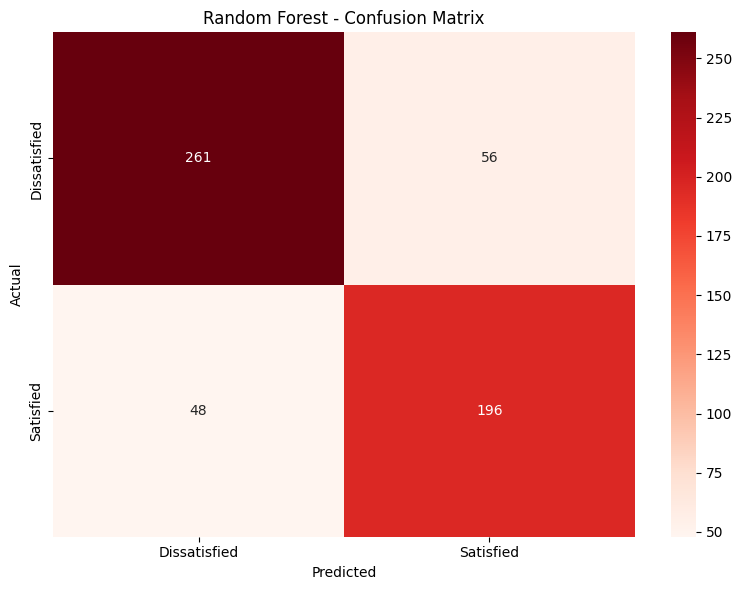

In [910]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

In [911]:
# Scale features for neural network (important for gradient-based optimization)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Features scaled for neural network training")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")

Features scaled for neural network training
Training data shape: (2242, 12)
Test data shape: (561, 12)


In [912]:
# Build Shallow FFNN model
print("Building Shallow Feed-Forward Neural Network...")

ffnn_model = keras.Sequential([
    # Input layer
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    # First hidden layer with 64 neurons
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.3),
    
    # Second hidden layer with 32 neurons
    layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    
    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
ffnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("\nModel Architecture:")
ffnn_model.summary()

Building Shallow Feed-Forward Neural Network...

Model Architecture:


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [913]:
# Train the FFNN model
print("Training Shallow FFNN...")
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = ffnn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")

Training Shallow FFNN...
Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6297 - loss: 0.6945 - precision_12: 0.5755 - recall_12: 0.4816 - val_accuracy: 0.7483 - val_loss: 0.6026 - val_precision_12: 0.7874 - val_recall_12: 0.6432
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7407 - loss: 0.5864 - precision_12: 0.7029 - recall_12: 0.6724 - val_accuracy: 0.7973 - val_loss: 0.5363 - val_precision_12: 0.8144 - val_recall_12: 0.7418
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7658 - loss: 0.5642 - precision_12: 0.7214 - recall_12: 0.7289 - val_accuracy: 0.8040 - val_loss: 0.5075 - val_precision_12: 0.7803 - val_recall_12: 0.8169
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7803 - loss: 0.5487 - precision_12: 0.7226 - recall_12: 0.7816 - val_accuracy: 0.8107 - val_loss: 0.5040 - val_precision_12: 0.7936 - val_recall_12: 0.8122
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7786 - loss: 0.5376 - pre

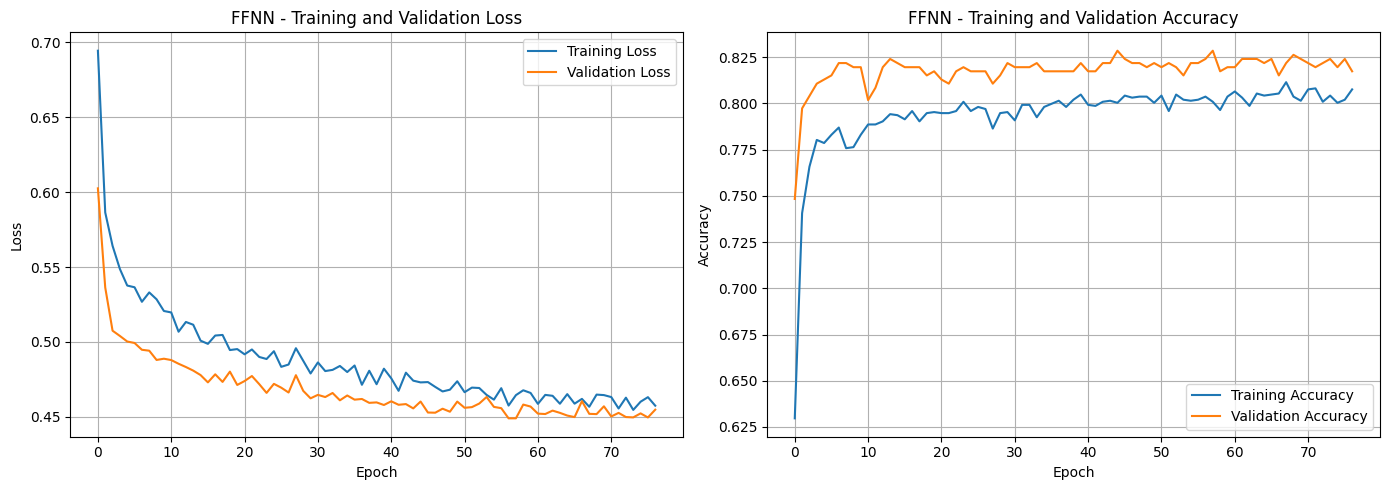

In [914]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('FFNN - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('FFNN - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [915]:
# Evaluate FFNN on test set
y_pred_ffnn_probs = ffnn_model.predict(X_test_scaled)
y_pred_ffnn = (y_pred_ffnn_probs > 0.5).astype(int).flatten()

print("="*60)
print("SHALLOW FFNN - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_ffnn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ffnn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_ffnn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_ffnn):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ffnn, target_names=['Dissatisfied', 'Satisfied']))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
SHALLOW FFNN - RESULTS

Accuracy:  0.8057
Precision: 0.7528
Recall:    0.8238
F1-Score:  0.7867

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.85      0.79      0.82       317
   Satisfied       0.75      0.82      0.79       244

    accuracy                           0.81       561
   macro avg       0.80      0.81      0.80       561
weighted avg       0.81      0.81      0.81       561



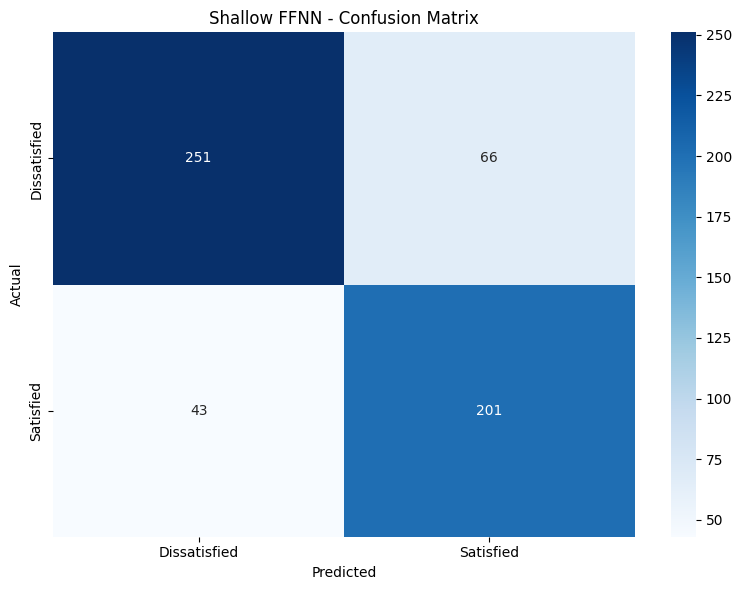

In [916]:
# Confusion Matrix for FFNN
cm_ffnn = confusion_matrix(y_test, y_pred_ffnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ffnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Shallow FFNN - Confusion Matrix')
plt.tight_layout()
plt.show()

PermutationExplainer explainer: 562it [00:39, 10.36it/s]                         
C:\Users\ahmos\AppData\Local\Temp\ipykernel_21936\3185257774.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


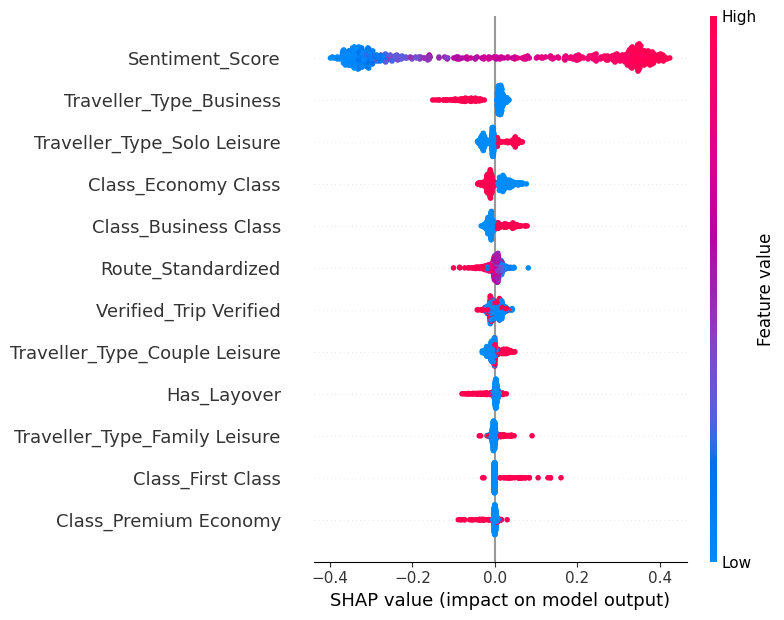

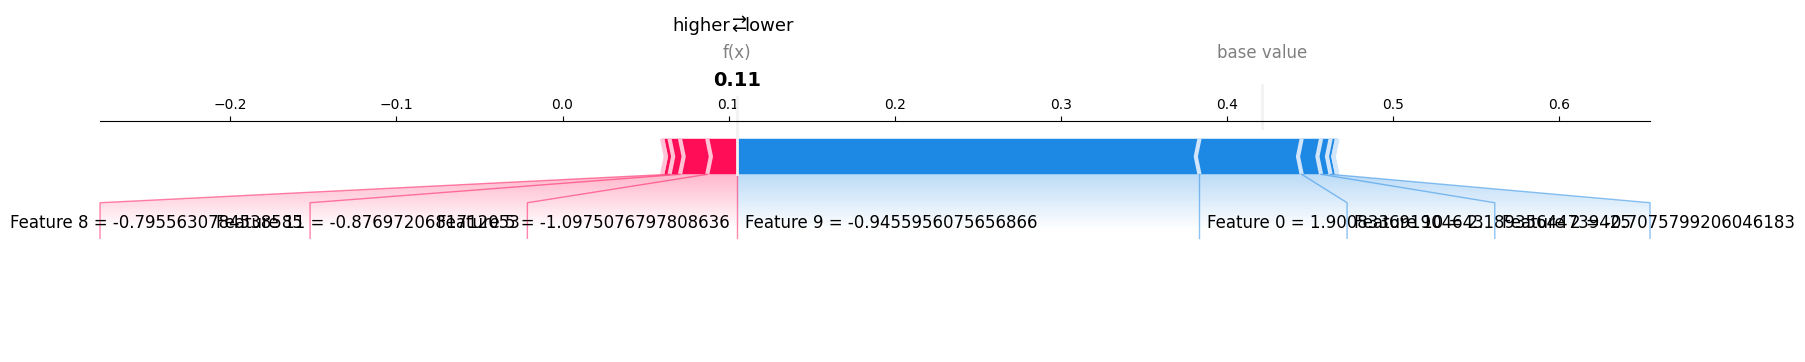

In [917]:
# Global SHAP
background = shap.sample(X_train_scaled, 100, random_state=42)
explainer = shap.Explainer(ffnn_model, background.values)
shap_values = explainer(X_test_scaled.values)

shap.summary_plot(
    shap_values.values,
    X_test_scaled,
    feature_names=feature_columns
)

# LOCAL SHAP
fig = shap.plots.force(shap_values[0], matplotlib=True, show=False)
for text in fig.findobj(plt.Text):
    text.set_color('black')

ax = plt.gca()
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')


plt.show()

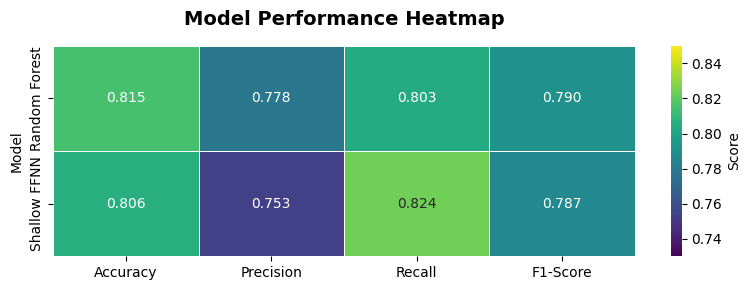

In [918]:
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Shallow FFNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ffnn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_ffnn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_ffnn)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_ffnn)
    ]
})

fig, ax = plt.subplots(figsize=(8, 3))
heatmap_data = comparison_df.set_index('Model')

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='viridis', 
            vmin=0.73, vmax=0.85, cbar_kws={'label': 'Score'},
            linewidths=0.5, ax=ax)

ax.set_title('Model Performance Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [919]:
def predict_satisfaction(input_df, model, scaler, encoder, label_encoder, sia):
    """
    Predict satisfaction for new passenger data using the Neural Network model.
    Applies all preprocessing steps from the training pipeline.
    
    Parameters:
    -----------
    input_df : pd.DataFrame
        DataFrame with one row containing raw unprocessed data
        Required columns: ['Review_content', 'Route_Standardized', 'Class', 
                          'Traveller_Type', 'Verified', 'Has_Layover']
    model : keras.Model
        Trained FFNN model
    scaler : StandardScaler
        Fitted scaler used during training
    encoder : OneHotEncoder
        Fitted one-hot encoder for categorical features
    label_encoder : LabelEncoder
        Fitted label encoder for Route_Standardized
    sia : SentimentIntensityAnalyzer
        VADER sentiment analyzer
        
    Returns:
    --------
    dict: Prediction results with probability and class
    """
    # Create a copy to avoid modifying original
    df = input_df.copy()
    
    # Step 1: Calculate sentiment score from review content
    if 'Review_content' in df.columns:
        df['Sentiment_Score'] = df['Review_content'].apply(
            lambda x: sia.polarity_scores(str(x))['compound'] if pd.notna(x) else 0
        )
    else:
        df['Sentiment_Score'] = 0
    
    # Step 2: Clean categorical features (remove Unknown/Various if present)
    if 'Class' in df.columns:
        if df['Class'].iloc[0] in ['Unknown']:
            raise ValueError("Class cannot be 'Unknown'")
    
    if 'Traveller_Type' in df.columns:
        if df['Traveller_Type'].iloc[0] in ['Unknown', 'Various']:
            raise ValueError("Traveller_Type cannot be 'Unknown' or 'Various'")
    
    # Step 3: One-hot encode categorical features
    categorical_cols = ['Class', 'Traveller_Type', 'Verified']
    one_hot_encoded = encoder.transform(df[categorical_cols])
    one_hot_df = pd.DataFrame(
        one_hot_encoded, 
        columns=encoder.get_feature_names_out(categorical_cols),
        index=df.index
    )
    
    # Step 4: Encode Route_Standardized
    if 'Route_Standardized' in df.columns:
        try:
            df['Route_Standardized'] = label_encoder.transform(df['Route_Standardized'])
        except:
            # If route not seen during training, use most common route encoding
            df['Route_Standardized'] = 0
    
    # Step 5: Combine features in correct order
    feature_columns = [
        'Traveller_Type_Business', 'Traveller_Type_Family Leisure', 
        'Traveller_Type_Couple Leisure', 'Traveller_Type_Solo Leisure',
        'Class_Business Class', 'Class_Economy Class', 
        'Class_First Class', 'Class_Premium Economy',
        'Verified_Trip Verified',
        'Sentiment_Score', 'Has_Layover', 'Route_Standardized'
    ]
    
    # Create final feature dataframe
    final_df = pd.DataFrame(index=df.index)
    
    # Add one-hot encoded columns
    for col in one_hot_df.columns:
        final_df[col] = one_hot_df[col]
    
    # Add numerical columns
    final_df['Sentiment_Score'] = df['Sentiment_Score']
    final_df['Has_Layover'] = df['Has_Layover']
    final_df['Route_Standardized'] = df['Route_Standardized']
    
    # Ensure all feature columns exist in correct order
    final_df = final_df[feature_columns]
    
    # Step 6: Scale features
    input_scaled = scaler.transform(final_df)
    
    # Step 7: Make prediction
    probability = model.predict(input_scaled, verbose=0)[0][0]
    prediction = 1 if probability > 0.5 else 0
    
    return {
        'prediction': 'Customer will be Satisfied, Enjoy your travels!' if prediction == 1 else 'Customer will be Dissatisfied,  Need to Address their concerns!!',
        'probability': float(probability),
        'confidence': float(max(probability, 1 - probability))
    }


# Example usage
print("="*70)
print("NEURAL NETWORK INFERENCE FUNCTION")
print("="*70)

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Test with raw unprocessed sample data
sample_1 = pd.DataFrame([{
    'Review_content': 'Excellent service, very comfortable flight and friendly staff. Highly recommend!',
    'Route_Standardized': 'London-New York',
    'Class': 'Business Class',
    'Traveller_Type': 'Business',
    'Verified': 'Trip Verified',
    'Has_Layover': 0
}])

result_1 = predict_satisfaction(
    input_df=sample_1,
    model=ffnn_model,
    scaler=scaler,
    encoder=encoder,
    label_encoder=label_encoder,
    sia=sia
)

print("\nSample 1 - Positive Review:")
print(f"Review: '{sample_1['Review_content'].iloc[0][:60]}...'")
print(f"Route: {sample_1['Route_Standardized'].iloc[0]}")
print(f"Class: {sample_1['Class'].iloc[0]}, Type: {sample_1['Traveller_Type'].iloc[0]}")
print(f"\n→ Prediction: {result_1['prediction']}")
print(f"  Probability: {result_1['probability']:.4f}")
print(f"  Confidence: {result_1['confidence']:.4f}")

# Test with negative review
sample_2 = pd.DataFrame([{
    'Review_content': 'amazing experience. Flight was on time, staff was nice, and seats were comfortable.',
    'Route_Standardized': 'Paris-London',
    'Class': 'Economy Class',
    'Traveller_Type': 'Family Leisure',
    'Verified': 'Trip Verified',
    'Has_Layover': 1
}])

result_2 = predict_satisfaction(
    input_df=sample_2,
    model=ffnn_model,
    scaler=scaler,
    encoder=encoder,
    label_encoder=label_encoder,
    sia=sia
)

print("\n" + "-"*70)
print("\nSample 2 - Positive Review:")
print(f"Review: '{sample_2['Review_content'].iloc[0][:60]}...'")
print(f"Route: {sample_2['Route_Standardized'].iloc[0]}")
print(f"Class: {sample_2['Class'].iloc[0]}, Type: {sample_2['Traveller_Type'].iloc[0]}")
print(f"\n→ Prediction: {result_2['prediction']}")
print(f"  Probability: {result_2['probability']:.4f}")
print(f"  Confidence: {result_2['confidence']:.4f}")

# Test with neutral review
sample_3 = pd.DataFrame([{
    'Review_content': 'No complaints and no problems!',
    'Route_Standardized': 'Dubai-London',
    'Class': 'Premium Economy',
    'Traveller_Type': 'Solo Leisure',
    'Verified': 'Trip Verified',
    'Has_Layover': 0
}])

result_3 = predict_satisfaction(
    input_df=sample_3,
    model=ffnn_model,
    scaler=scaler,
    encoder=encoder,
    label_encoder=label_encoder,
    sia=sia
)

print("\n" + "-"*70)
print("\nSample 3 - Neutral Review:")
print(f"Review: '{sample_3['Review_content'].iloc[0][:60]}...'")
print(f"Route: {sample_3['Route_Standardized'].iloc[0]}")
print(f"Class: {sample_3['Class'].iloc[0]}, Type: {sample_3['Traveller_Type'].iloc[0]}")
print(f"\n→ Prediction: {result_3['prediction']}")
print(f"  Probability: {result_3['probability']:.4f}")
print(f"  Confidence: {result_3['confidence']:.4f}")

print("\n" + "="*70)

NEURAL NETWORK INFERENCE FUNCTION

Sample 1 - Positive Review:
Review: 'Excellent service, very comfortable flight and friendly staf...'
Route: London-New York
Class: Business Class, Type: Business

→ Prediction: Customer will be Satisfied, Enjoy your travels!
  Probability: 0.6896
  Confidence: 0.6896

----------------------------------------------------------------------

Sample 2 - Positive Review:
Review: 'amazing experience. Flight was on time, staff was nice, and ...'
Route: Paris-London
Class: Economy Class, Type: Family Leisure

→ Prediction: Customer will be Satisfied, Enjoy your travels!
  Probability: 0.7954
  Confidence: 0.7954

----------------------------------------------------------------------

Sample 3 - Neutral Review:
Review: 'No complaints and no problems!...'
Route: Dubai-London
Class: Premium Economy, Type: Solo Leisure

→ Prediction: Customer will be Dissatisfied,  Need to Address their concerns!!
  Probability: 0.1135
  Confidence: 0.8865



# **Distribution of top 10 routes bookings across flight hours**

In [922]:
eqdf = pd.read_csv(r"../AirlineScrappedReview_Processed_StandardizedRoutes.csv")
eqdf2 = pd.read_csv(r"../../Passanger_booking_data.csv")
eqdf2 = eqdf2.drop_duplicates()

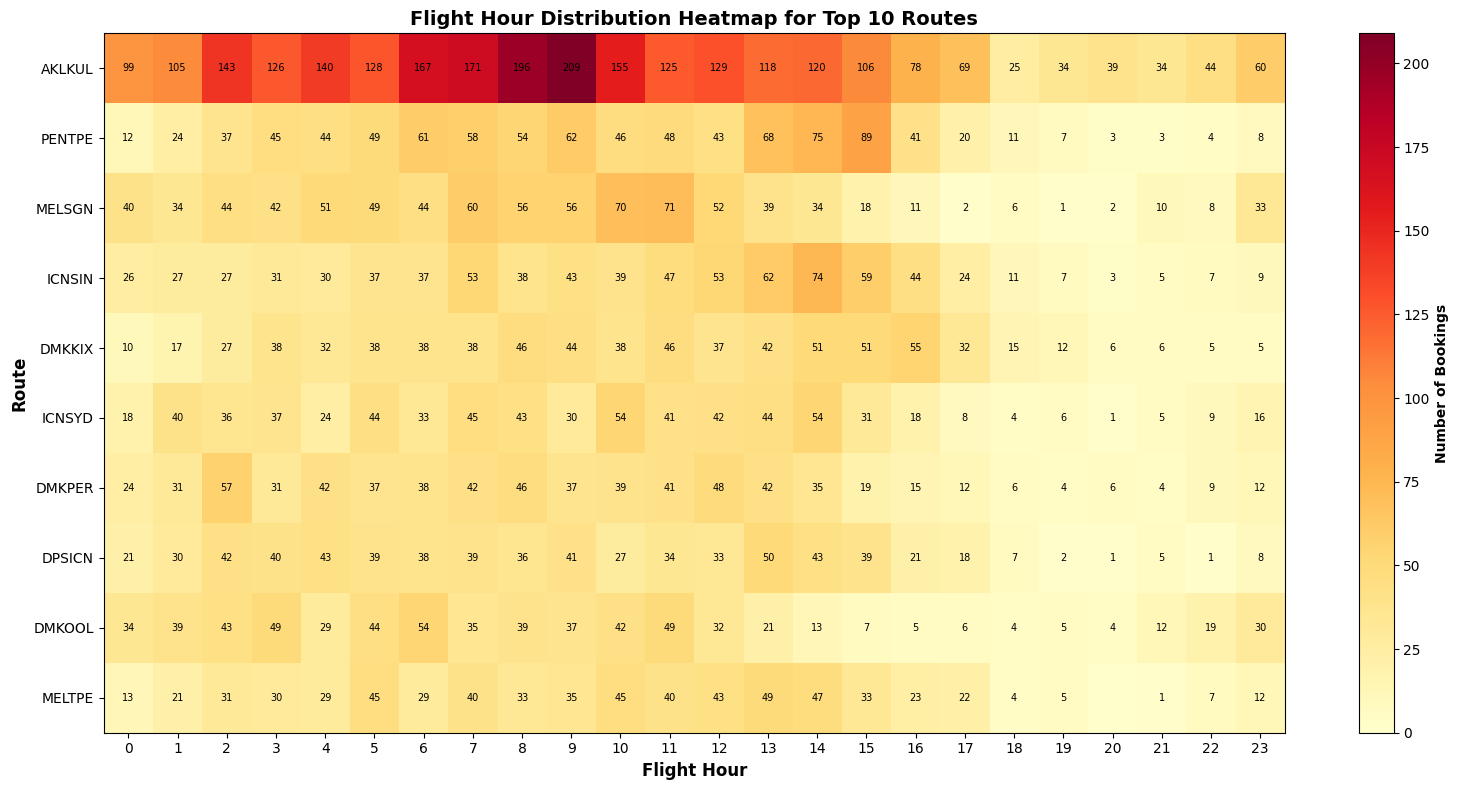

In [923]:
import matplotlib.pyplot as plt
import numpy as np

# Get top 10 routes and create heatmap data
top_10_routes = eqdf2['route'].value_counts().head(10).index.tolist()
heatmap_data = []
for route in top_10_routes:
    route_data = eqdf2[eqdf2['route'] == route]
    hour_counts = route_data['flight_hour'].value_counts().reindex(range(24), fill_value=0)
    heatmap_data.append(hour_counts.values)

heatmap_array = np.array(heatmap_data)

# Create heatmap
fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(heatmap_array, cmap='YlOrRd', aspect='auto')

# Set labels and title
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(10))
ax.set_yticklabels(top_10_routes)
ax.set_xlabel('Flight Hour', fontweight='bold', fontsize=12)
ax.set_ylabel('Route', fontweight='bold', fontsize=12)
ax.set_title('Flight Hour Distribution Heatmap for Top 10 Routes', fontweight='bold', fontsize=14)

# Add colorbar and annotations
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Number of Bookings', fontweight='bold')

for i in range(len(top_10_routes)):
    for j in range(24):
        if heatmap_array[i, j] > 0:
            ax.text(j, i, int(heatmap_array[i, j]), ha="center", va="center", color="black", fontsize=7)

plt.tight_layout()
plt.show()

Top 10 Routes: AKLUKUL, PENTPE, MELSGN, ICNSIN, DMKKIX, ICNSYD, DMKPER, DPSICN, DMKOOL, MELTPE

# **Traveler type and Class combination with highest and lowest ratings**

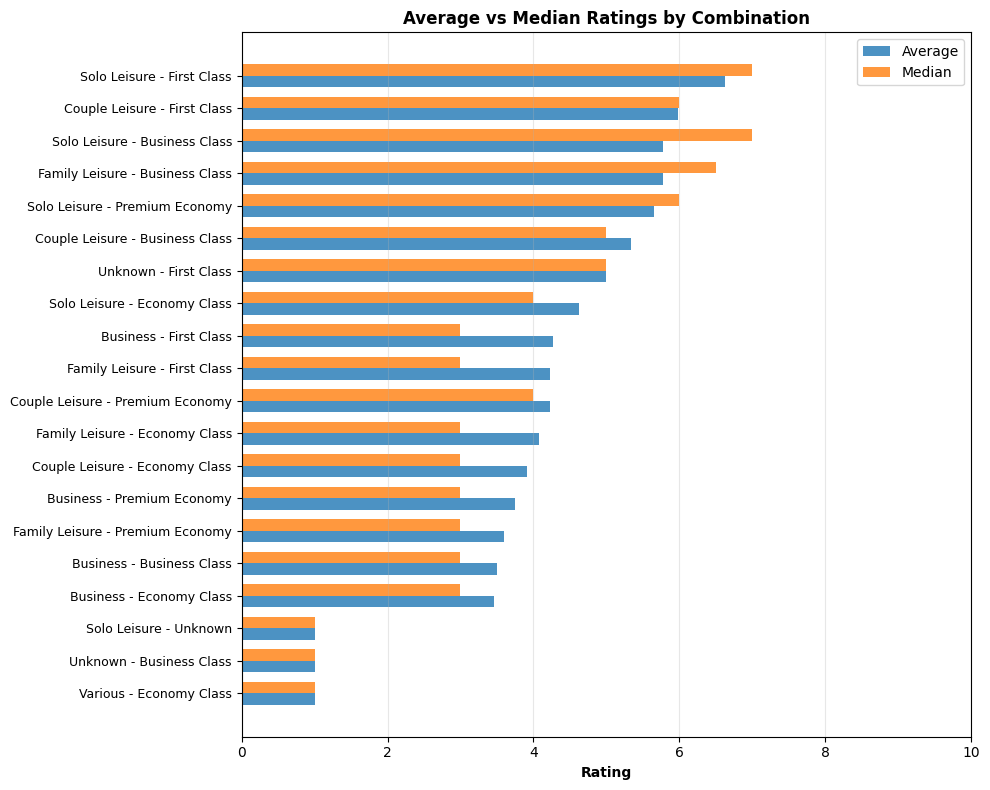

C:\Users\ahmos\AppData\Local\Temp\ipykernel_21936\776185883.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eqdf, y='Combination', x='Rating', order=combination_order, ax=ax2, palette='RdYlGn')


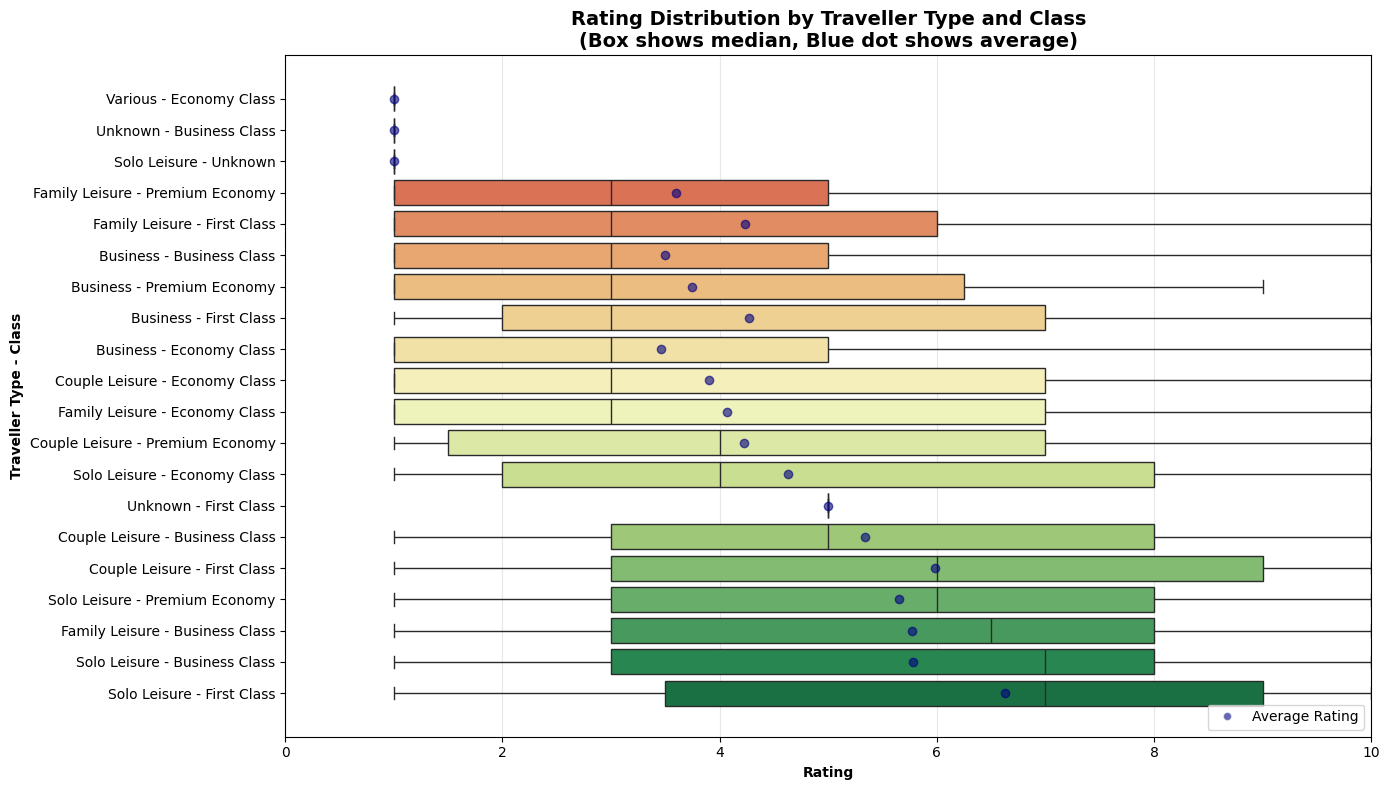

In [924]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate statistics
rating_stats = eqdf.groupby(['Traveller_Type', 'Class'])['Rating'].agg(['mean', 'median']).reset_index()
rating_stats.columns = ['Traveller_Type', 'Class', 'Average_Rating', 'Median_Rating']
rating_stats['Combination'] = rating_stats['Traveller_Type'] + ' - ' + rating_stats['Class']
rating_stats_sorted = rating_stats.sort_values('Average_Rating', ascending=True)

# Bar chart: Average vs Median
fig1, ax1 = plt.subplots(figsize=(10, 8))
x = np.arange(len(rating_stats_sorted))
width = 0.35
ax1.barh(x - width/2, rating_stats_sorted['Average_Rating'], width, label='Average', alpha=0.8)
ax1.barh(x + width/2, rating_stats_sorted['Median_Rating'], width, label='Median', alpha=0.8)
ax1.set_yticks(x)
ax1.set_yticklabels(rating_stats_sorted['Combination'], fontsize=9)
ax1.set_xlabel('Rating', fontweight='bold')
ax1.set_title('Average vs Median Ratings by Combination', fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)
ax1.set_xlim(0, 10)
plt.tight_layout()
plt.show()

# Boxplot with average markers
fig2, ax2 = plt.subplots(figsize=(14, 8))
eqdf['Combination'] = eqdf['Traveller_Type'] + ' - ' + eqdf['Class']
combination_order = eqdf.groupby('Combination')['Rating'].median().sort_values().index

sns.boxplot(data=eqdf, y='Combination', x='Rating', order=combination_order, ax=ax2, palette='RdYlGn')

# Add average markers
for i, combo in enumerate(combination_order):
    avg_rating = eqdf[eqdf['Combination'] == combo]['Rating'].mean()
    ax2.plot(avg_rating, i, marker='o', color='navy', markersize=6, alpha=0.6, zorder=3)

from matplotlib.lines import Line2D
ax2.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor='navy',
                           markersize=6, alpha=0.6, label='Average Rating')], loc='lower right')
ax2.set_title('Rating Distribution by Traveller Type and Class\n(Box shows median, Blue dot shows average)',
              fontweight='bold', fontsize=14)
ax2.set_xlabel('Rating', fontweight='bold')
ax2.set_ylabel('Traveller Type - Class', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.set_xlim(0, 10)
plt.tight_layout()
plt.show()

First Class and Business Class Solo Leisure have the highest median rating at 7.0 meaning they yielded the best results.

---

Economy Class and Business Class Business have the lowest median rating at 3.0 meaning they yielded the worst results.